# Predicting Network Flow Duration in Real-Time IoT Environments: A Comparative Analysis of Gradient Boosting Ensembles and Deep Sequential Architectures

---

**Student:** Jatin Kumar (25171403)  
**Module:** CMP7239 — Applied Machine Learning  
**Institution:** Birmingham City University  
**Dataset:** RT-IoT2022 (UCI Machine Learning Repository, ID: 942)  
**Task:** Supervised Regression — Predicting `flow_duration`

---

**Abstract:** This study investigates the prediction of network flow duration in IoT environments using the RT-IoT2022 dataset (123,117 records, 50 features). A rigorous four-stage feature selection pipeline reduces dimensionality from 50 to an optimal subset, evaluated across four dataset variations. Six regression models — XGBoost, LightGBM, CatBoost, Elastic Net, LSTM, and 1D-CNN — are trained and compared using R², RMSE, MAE, MSE, and MAPE. The prohibited algorithms (Decision Tree, Random Forest, KNN, MLP, DNN/ANN) are excluded per experimental constraints, focusing instead on gradient boosting ensembles and deep sequential architectures.

---

## 1. Environment Setup & Dependencies

In [1]:
# ════════════════════════════════════════════════════════════
# 1.1 Install Required Packages
# ════════════════════════════════════════════════════════════
# XGBoost, LightGBM, and CatBoost are the three gradient
# boosting frameworks evaluated. TensorFlow/Keras provides
# LSTM and 1D-CNN deep learning architectures.
# ════════════════════════════════════════════════════════════

!pip install -q xgboost lightgbm catboost scikit-learn pandas numpy matplotlib seaborn tensorflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.2 MB/s eta 0:00:00


In [2]:
# ════════════════════════════════════════════════════════════
# 1.2 Import Libraries
# ════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
import time
import joblib
import os

warnings.filterwarnings('ignore')

# Scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (mean_absolute_error, mean_squared_error,
                             r2_score, mean_absolute_percentage_error)
from sklearn.feature_selection import mutual_info_regression, VarianceThreshold
from sklearn.linear_model import ElasticNet, LassoCV
from sklearn.base import clone

# Gradient Boosting Ensembles
from xgboost import XGBRegressor
import lightgbm as lgb
from catboost import CatBoostRegressor

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (LSTM, Conv1D, Dense, Dropout,
                                      Flatten, MaxPooling1D, Reshape,
                                      BatchNormalization)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# ── Publication-Quality Plot Settings ──
plt.rcParams.update({
    'figure.figsize': (10, 6),
    'figure.dpi': 150,
    'font.size': 11,
    'font.family': 'serif',
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'legend.fontsize': 10,
    'axes.grid': True,
    'grid.alpha': 0.3,
    'axes.spines.top': False,
    'axes.spines.right': False,
})
PALETTE = ['#2E86C1', '#E74C3C', '#27AE60', '#F39C12', '#8E44AD', '#1ABC9C']
sns.set_palette(PALETTE)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)

print(f"TensorFlow: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")
print("All libraries imported successfully.")

TensorFlow: 2.19.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
All libraries imported successfully.


## 2. Data Loading & Inspection

In [3]:
# ════════════════════════════════════════════════════════════
# 2.1 Load Dataset
# ════════════════════════════════════════════════════════════

from google.colab import files
uploaded = files.upload()
filename = list(uploaded.keys())[0]
df = pd.read_csv(filename)

print(f"Dataset: {df.shape[0]:,} records × {df.shape[1]} columns")
print(f"Memory:  {df.memory_usage(deep=True).sum()/1e6:.1f} MB")

Saving rt_iot2022_regression_ready_50_features.csv to rt_iot2022_regression_ready_50_features.csv
Dataset: 123,117 records × 51 columns
Memory:  60.9 MB


In [4]:
# ════════════════════════════════════════════════════════════
# 2.2 Data Quality Audit
# ════════════════════════════════════════════════════════════

print("DATA QUALITY AUDIT")
print("=" * 55)
print(f"Records:          {df.shape[0]:,}")
print(f"Features:         {df.shape[1] - 1} + 1 target")
print(f"Numeric features: {df.select_dtypes(include='number').shape[1] - 1}")
print(f"Categorical:      {df.select_dtypes(exclude='number').shape[1]}")
print(f"Missing values:   {df.isnull().sum().sum()}")
print(f"Infinite values:  {np.isinf(df.select_dtypes(include='number')).sum().sum()}")
print(f"Duplicate rows:   {df.duplicated().sum():,}")
print("=" * 55)

# Descriptive statistics
df.describe().T.round(4)

DATA QUALITY AUDIT
Records:          123,117
Features:         50 + 1 target
Numeric features: 48
Categorical:      2
Missing values:   0
Infinite values:  0
Duplicate rows:   5,202


,count,mean,std,min,25%,50%,75%,max
id.orig_p,123117.0,3.463926e+04,1.907062e+04,0.0,17702.0000,37221.0000,5.097100e+04,6.553500e+04
id.resp_p,123117.0,1.014305e+03,5.256372e+03,0.0,21.0000,21.0000,2.100000e+01,6.538900e+04
fwd_pkts_tot,123117.0,2.268800e+00,2.233660e+01,0.0,1.0000,1.0000,1.000000e+00,4.345000e+03
bwd_pkts_tot,123117.0,1.909500e+00,3.301830e+01,0.0,1.0000,1.0000,1.000000e+00,1.011200e+04
fwd_data_pkts_tot,123117.0,1.471200e+00,1.963520e+01,0.0,1.0000,1.0000,1.000000e+00,4.345000e+03
bwd_data_pkts_tot,123117.0,8.203000e-01,3.229390e+01,0.0,0.0000,0.0000,0.000000e+00,1.010500e+04
fwd_pkts_per_sec,123117.0,3.518063e+05,3.707645e+05,0.0,74.5435,246723.7647,5.242880e+05,1.048576e+06
bwd_pkts_per_sec,123117.0,3.517620e+05,3.708015e+05,0.0,72.8893,246723.7647,5.242880e+05,1.048576e+06
flow_pkts_per_sec,123117.0,7.035683e+05,7.415634e+05,0.0,149.0871,493447.5294,1.048576e+06,2.097152e+06
down_up_ratio,123117.0,8.546000e-01,3.376000e-01,0.0,1.0000,1.0000,1.000000e+00,6.087900e+00


## 3. Exploratory Data Analysis (EDA)

This section provides a systematic examination of the dataset's statistical properties, distributions, and inter-feature relationships, following established EDA frameworks (Tukey, 1977).

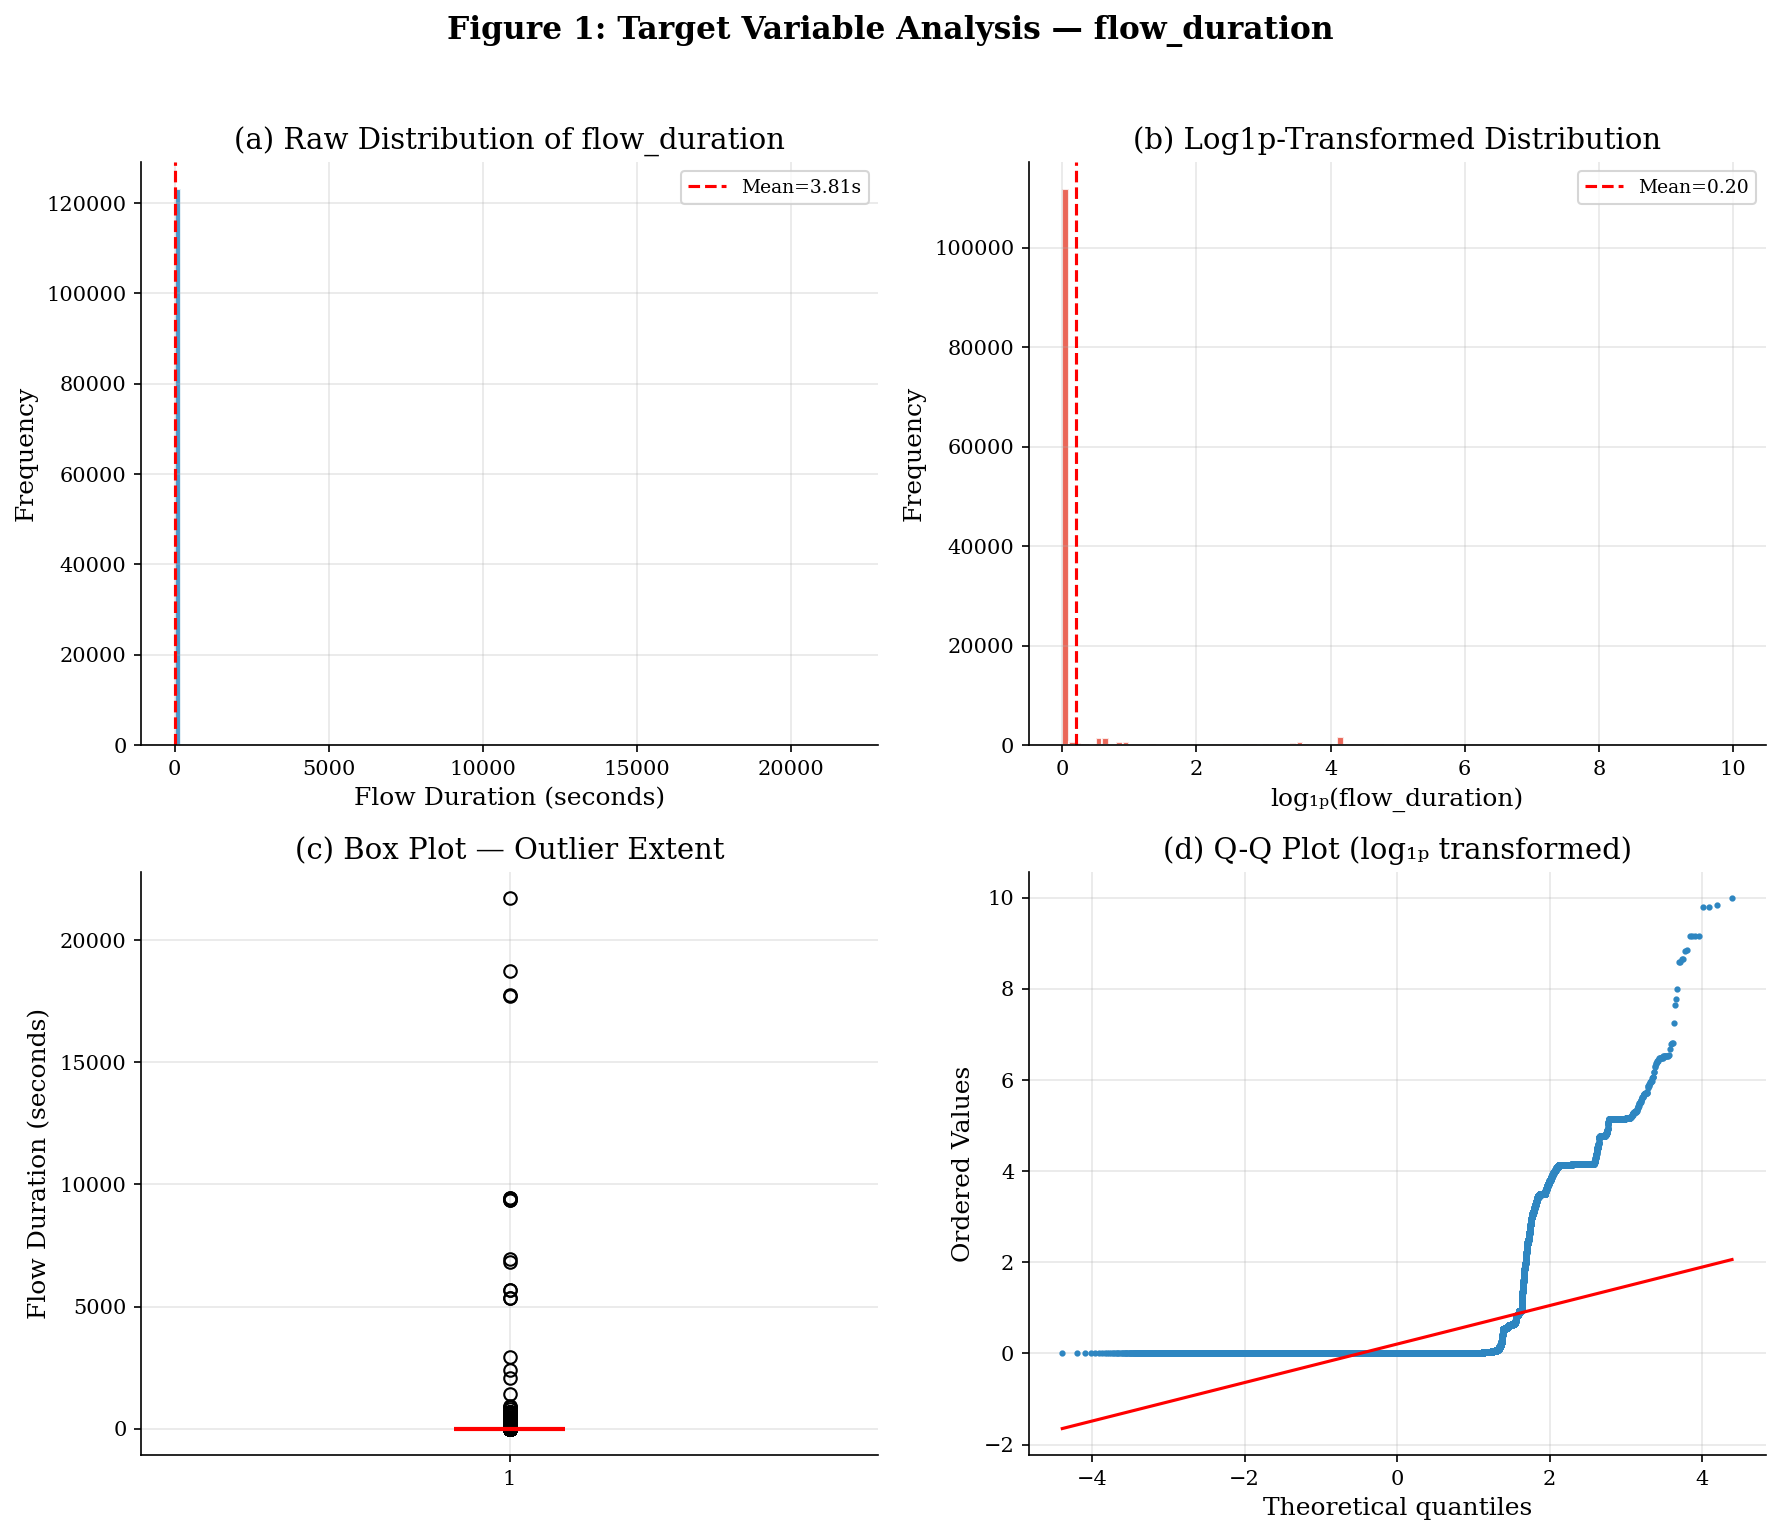


Skewness: 120.96 → 4.43 (after log1p)
Kurtosis: 16604.65 → 19.70 (after log1p)


In [5]:
# ════════════════════════════════════════════════════════════
# 3.1 Target Variable Analysis — flow_duration
# ════════════════════════════════════════════════════════════

target = df['flow_duration']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# (a) Raw distribution
axes[0,0].hist(target, bins=100, color=PALETTE[0], edgecolor='white', alpha=0.85)
axes[0,0].axvline(target.mean(), color='red', ls='--', lw=1.5, label=f'Mean={target.mean():.2f}s')
axes[0,0].set_title('(a) Raw Distribution of flow_duration')
axes[0,0].set_xlabel('Flow Duration (seconds)')
axes[0,0].set_ylabel('Frequency')
axes[0,0].legend(fontsize=9)

# (b) Log1p transformed
log_target = np.log1p(target)
axes[0,1].hist(log_target, bins=100, color=PALETTE[1], edgecolor='white', alpha=0.85)
axes[0,1].axvline(log_target.mean(), color='red', ls='--', lw=1.5, label=f'Mean={log_target.mean():.2f}')
axes[0,1].set_title('(b) Log1p-Transformed Distribution')
axes[0,1].set_xlabel('log₁ₚ(flow_duration)')
axes[0,1].set_ylabel('Frequency')
axes[0,1].legend(fontsize=9)

# (c) Box plot
bp = axes[1,0].boxplot(target, vert=True, patch_artist=True,
                       boxprops=dict(facecolor=PALETTE[0], alpha=0.6),
                       medianprops=dict(color='red', lw=2))
axes[1,0].set_title('(c) Box Plot — Outlier Extent')
axes[1,0].set_ylabel('Flow Duration (seconds)')

# (d) Q-Q plot
from scipy import stats
stats.probplot(log_target, dist='norm', plot=axes[1,1])
axes[1,1].set_title('(d) Q-Q Plot (log₁ₚ transformed)')
axes[1,1].get_lines()[0].set_color(PALETTE[0])
axes[1,1].get_lines()[0].set_markersize(2)
axes[1,1].get_lines()[1].set_color('red')

plt.suptitle('Figure 1: Target Variable Analysis — flow_duration',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig1_target_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nSkewness: {target.skew():.2f} → {log_target.skew():.2f} (after log1p)")
print(f"Kurtosis: {target.kurtosis():.2f} → {log_target.kurtosis():.2f} (after log1p)")

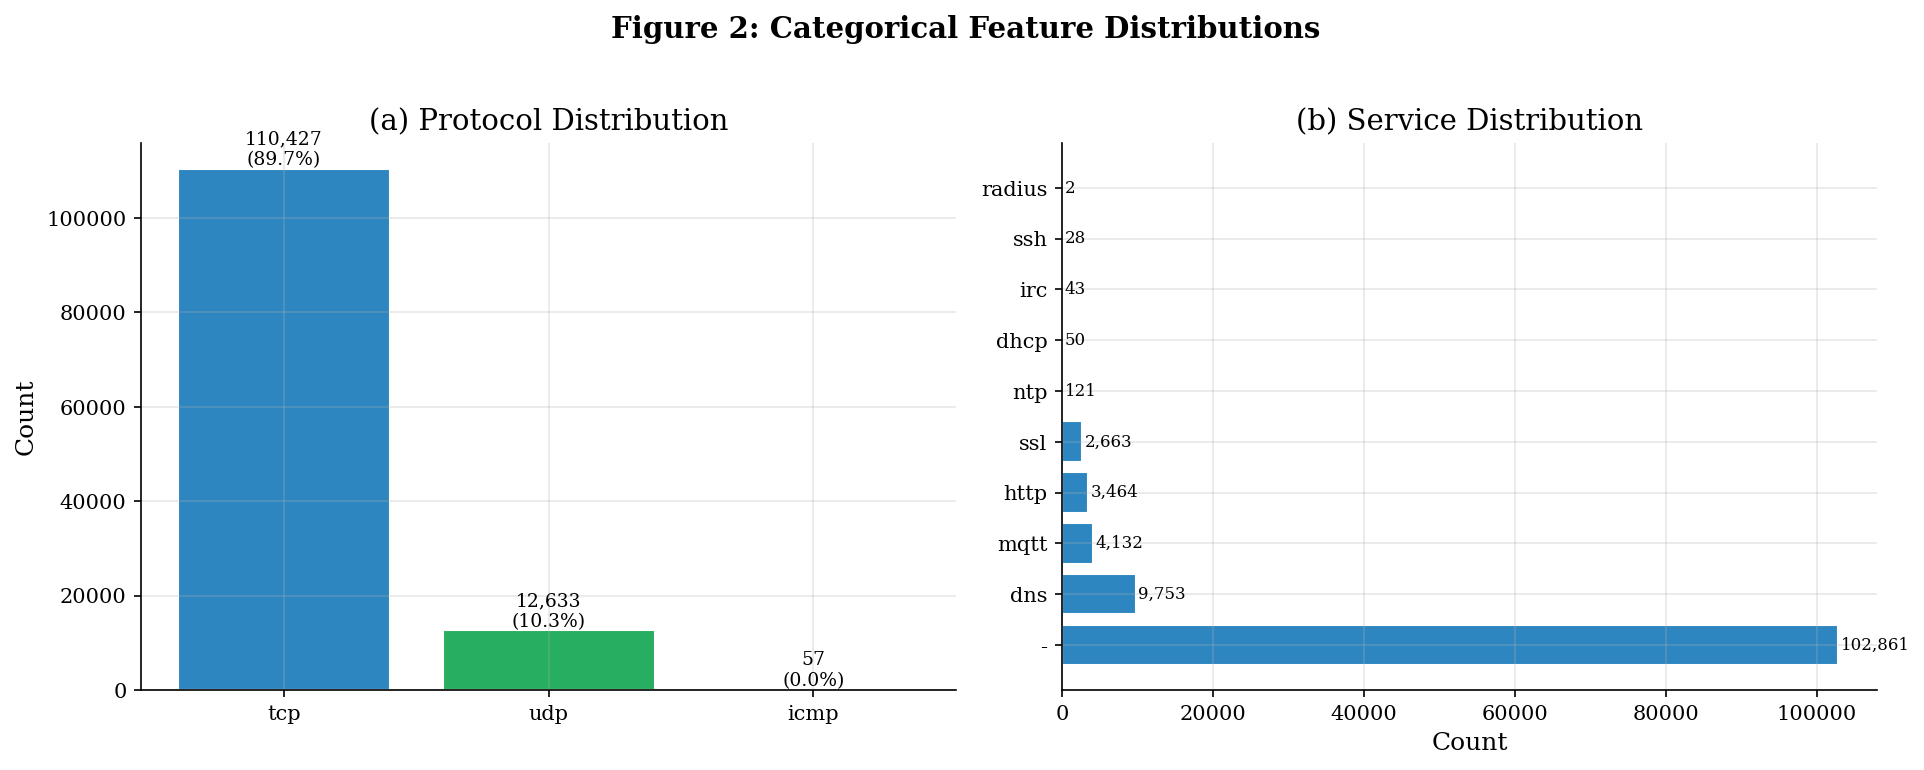

In [6]:
# ════════════════════════════════════════════════════════════
# 3.2 Categorical Feature Distribution
# ════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Protocol
proto_counts = df['proto'].value_counts()
bars1 = axes[0].bar(proto_counts.index, proto_counts.values,
                    color=[PALETTE[0], PALETTE[2], PALETTE[3]], edgecolor='white')
axes[0].set_title('(a) Protocol Distribution')
axes[0].set_ylabel('Count')
for bar, val in zip(bars1, proto_counts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+800,
                 f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=9)

# Service
svc_counts = df['service'].value_counts()
axes[1].barh(svc_counts.index, svc_counts.values, color=PALETTE[0], edgecolor='white')
axes[1].set_title('(b) Service Distribution')
axes[1].set_xlabel('Count')
for i, val in enumerate(svc_counts.values):
    axes[1].text(val+300, i, f'{val:,}', va='center', fontsize=8)

plt.suptitle('Figure 2: Categorical Feature Distributions',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig2_categorical.png', dpi=300, bbox_inches='tight')
plt.show()

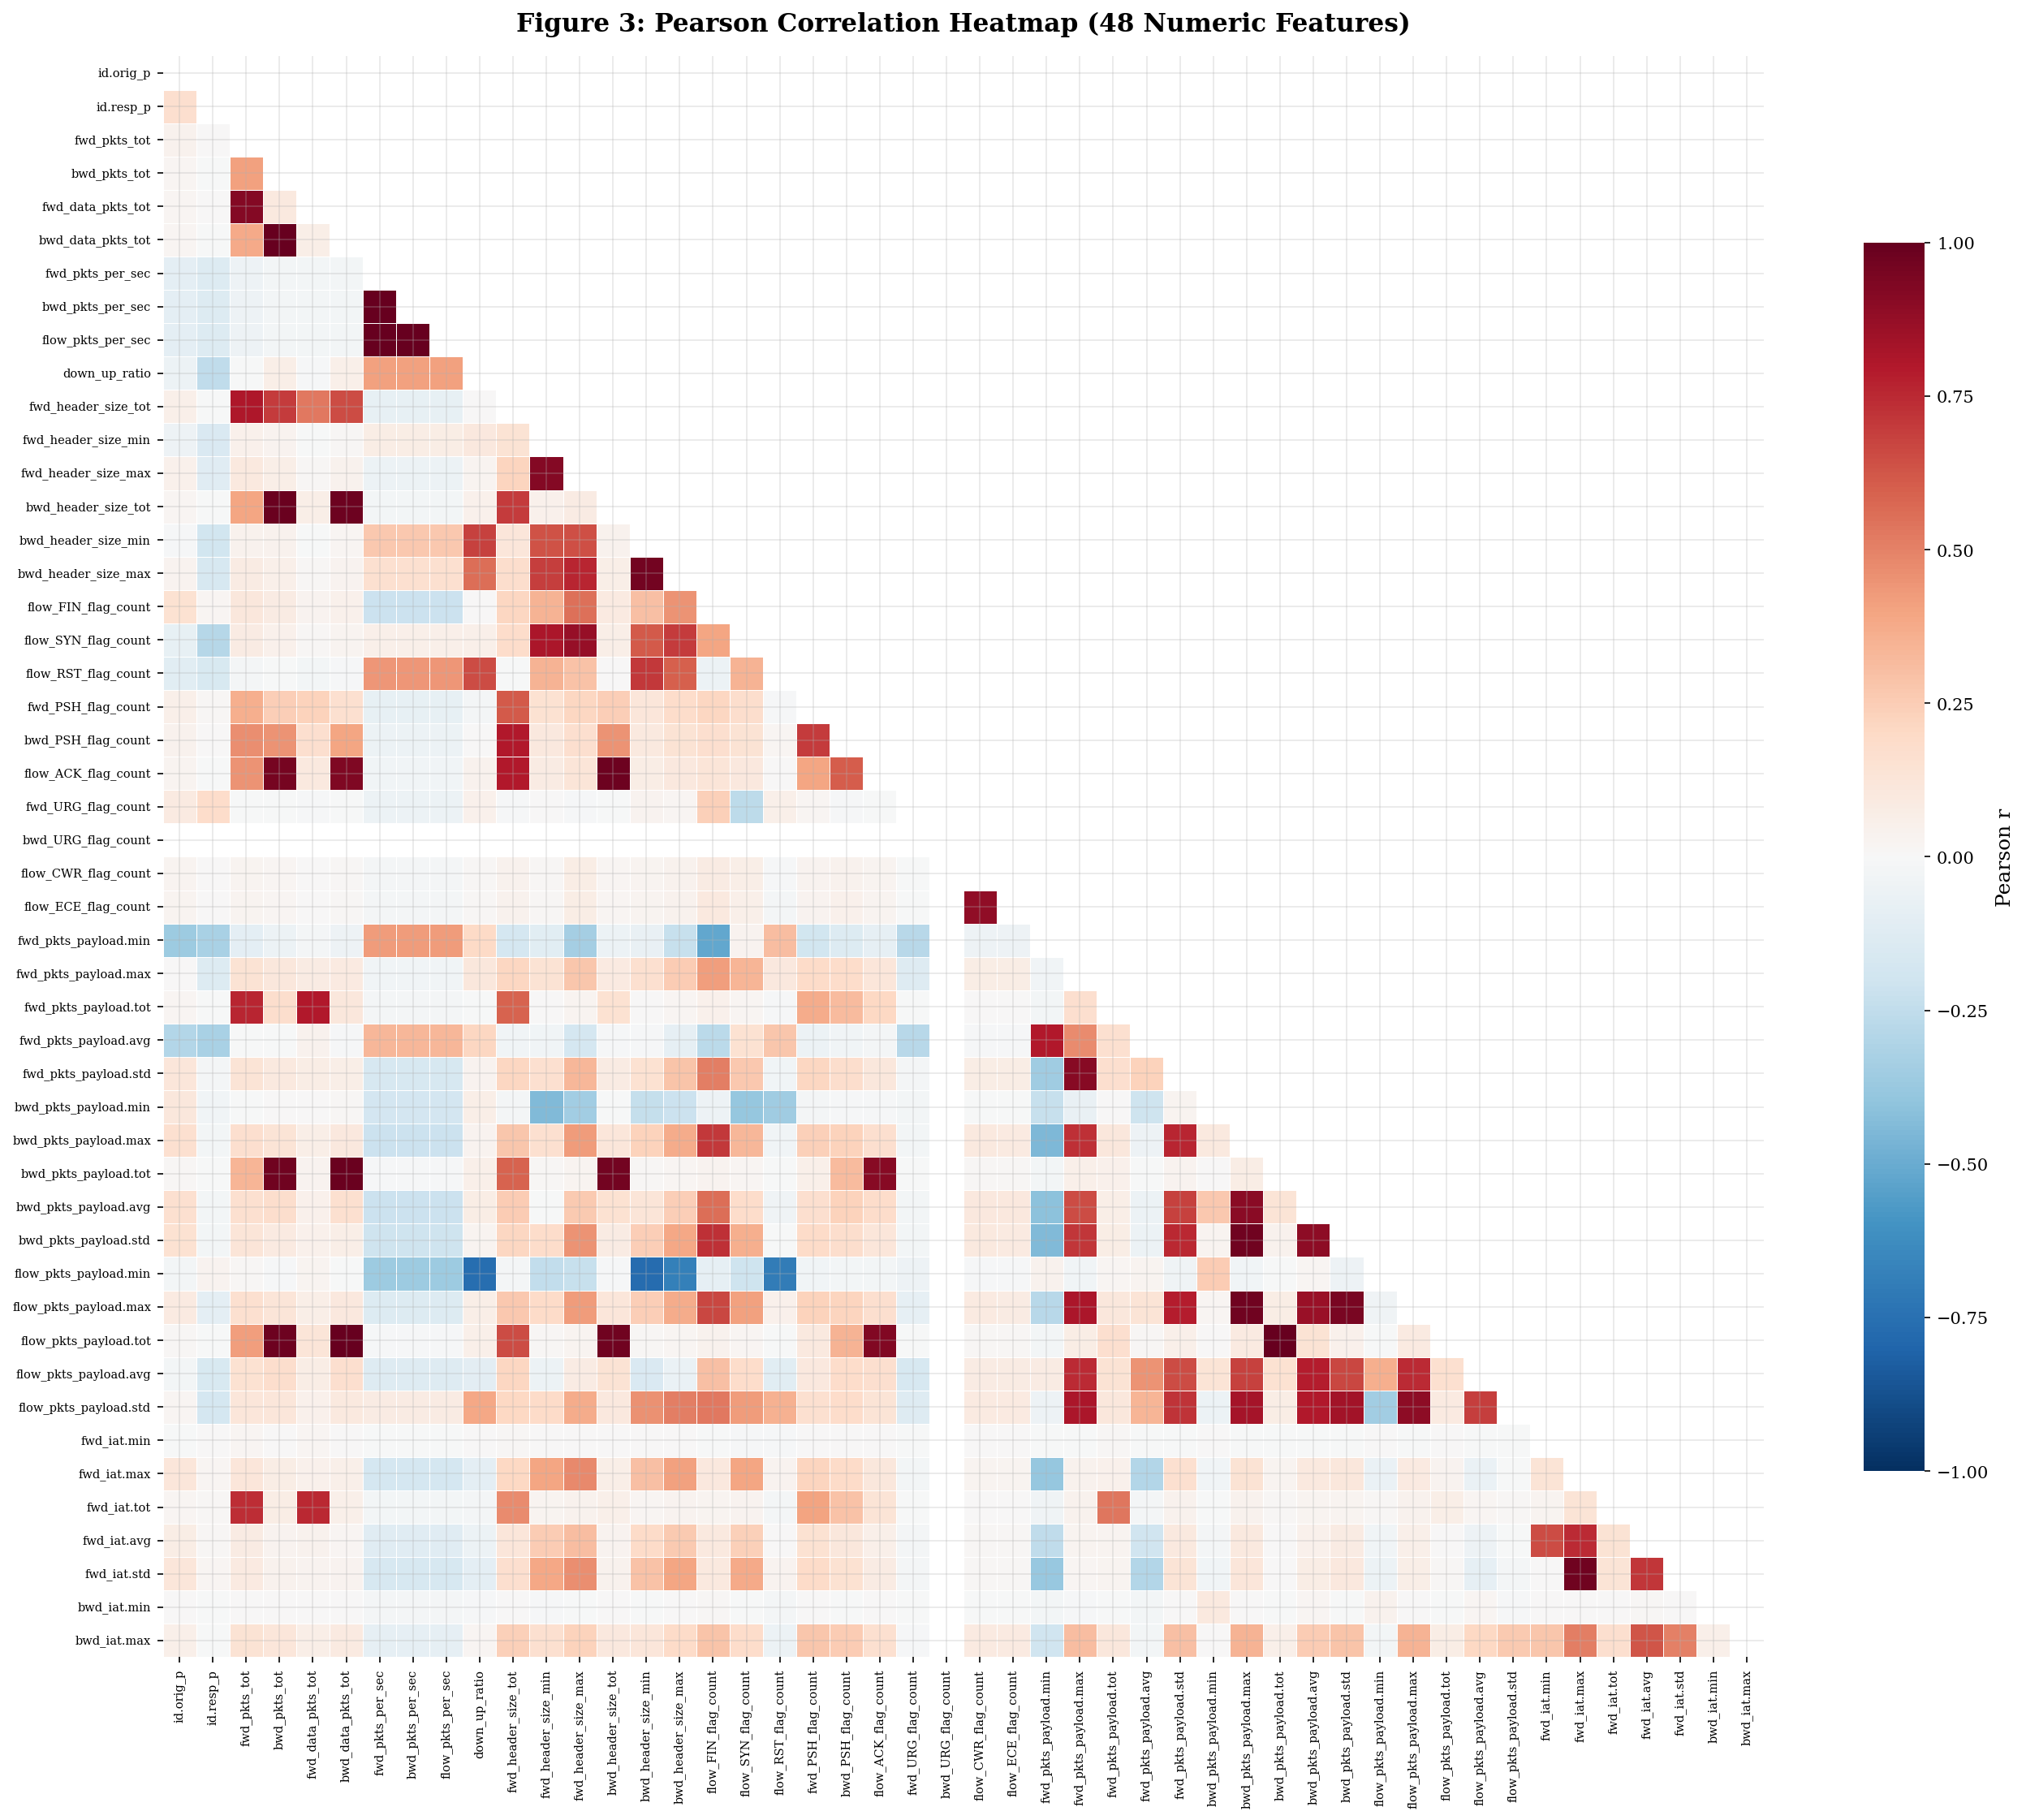

Feature pairs with |r| > 0.95: 19


In [7]:
# ════════════════════════════════════════════════════════════
# 3.3 Correlation Heatmap (Full Feature Matrix)
# ════════════════════════════════════════════════════════════

numeric_cols = df.select_dtypes(include='number').columns.tolist()
numeric_cols.remove('flow_duration')

corr_matrix = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(18, 15))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0,
            square=True, linewidths=0.3, cbar_kws={'shrink': 0.75, 'label': 'Pearson r'},
            vmin=-1, vmax=1, ax=ax, xticklabels=True, yticklabels=True)
ax.set_title('Figure 3: Pearson Correlation Heatmap (48 Numeric Features)',
             fontsize=15, fontweight='bold', pad=15)
ax.tick_params(axis='both', labelsize=7)
plt.tight_layout()
plt.savefig('fig3_correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

# Count high-correlation pairs
upper_tri = corr_matrix.abs().where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_pairs = [(c, r, corr_matrix.abs().loc[r,c])
              for c in upper_tri.columns for r in upper_tri.index
              if pd.notna(upper_tri.loc[r,c]) and upper_tri.loc[r,c] > 0.95]
print(f"Feature pairs with |r| > 0.95: {len(high_pairs)}")

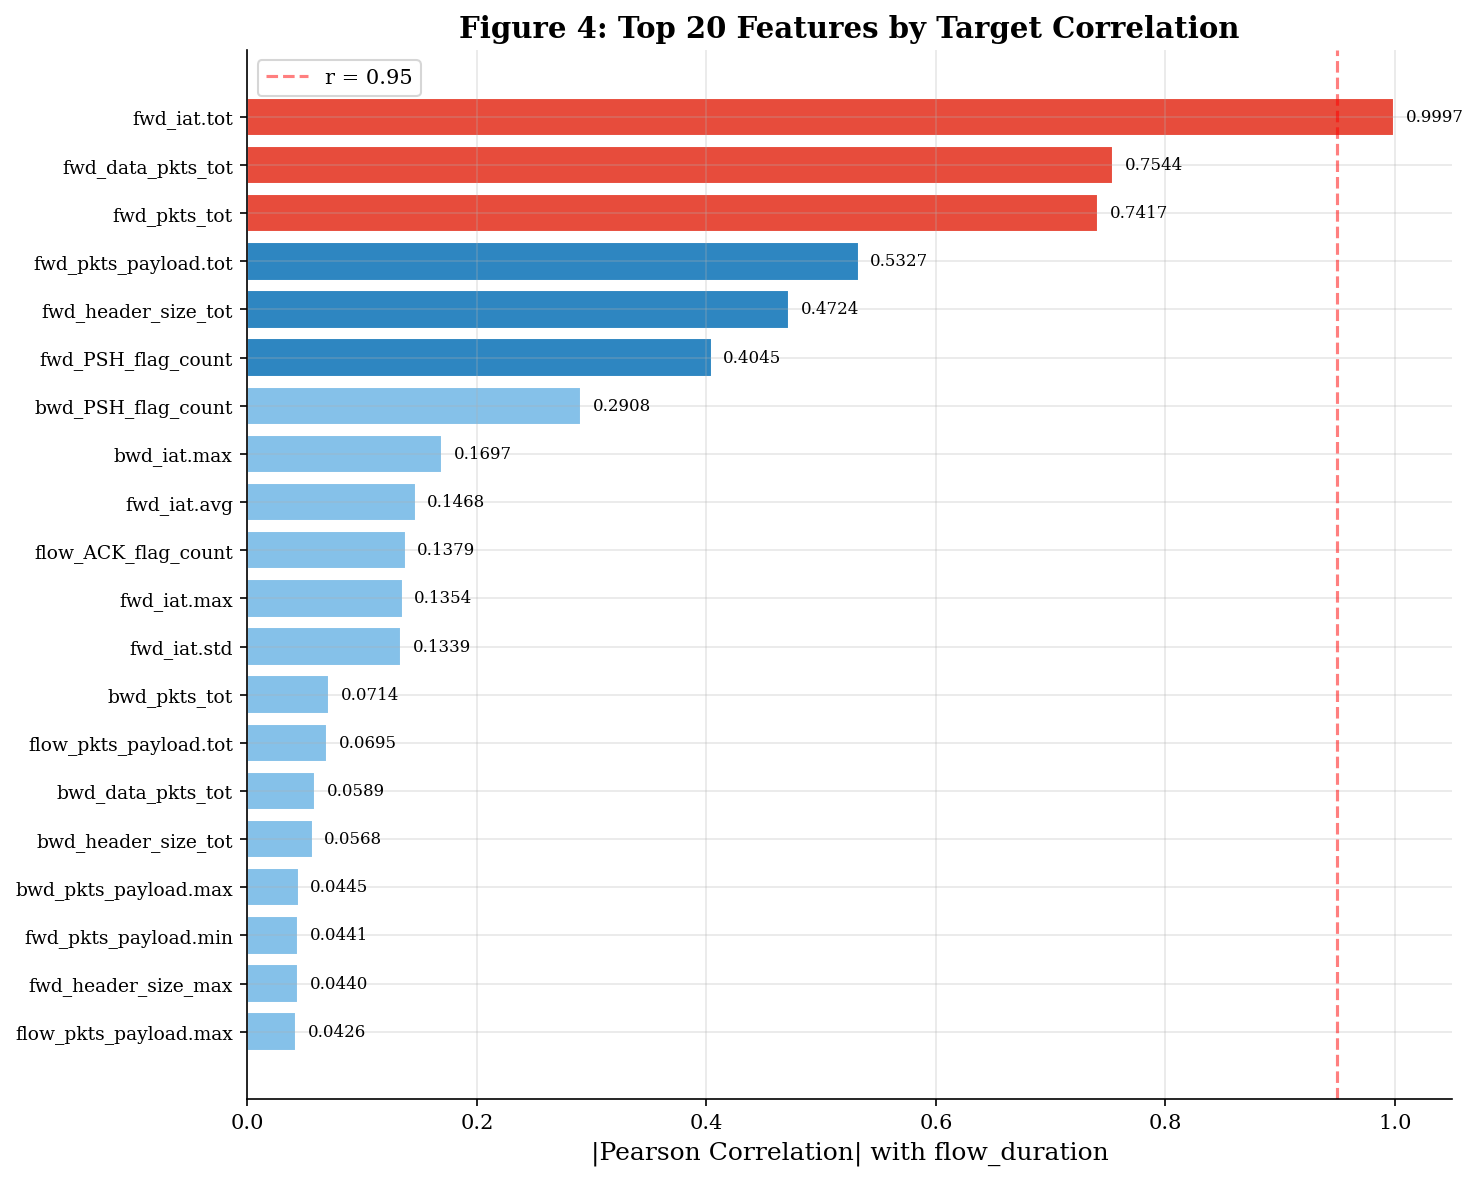

In [8]:
# ════════════════════════════════════════════════════════════
# 3.4 Top Feature Correlations with Target
# ════════════════════════════════════════════════════════════

target_corr = df[numeric_cols + ['flow_duration']].corr()['flow_duration'] \
              .drop('flow_duration').abs().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
top20 = target_corr.head(20)
colors = ['#E74C3C' if v > 0.7 else '#2E86C1' if v > 0.3 else '#85C1E9' for v in top20.values]
bars = ax.barh(range(len(top20)), top20.values, color=colors, edgecolor='white')
ax.set_yticks(range(len(top20)))
ax.set_yticklabels(top20.index, fontsize=9)
ax.invert_yaxis()
ax.set_xlabel('|Pearson Correlation| with flow_duration')
ax.set_title('Figure 4: Top 20 Features by Target Correlation',
             fontsize=14, fontweight='bold')
ax.axvline(0.95, color='red', ls='--', alpha=0.5, label='r = 0.95')
for i, val in enumerate(top20.values):
    ax.text(val+0.01, i, f'{val:.4f}', va='center', fontsize=8)
ax.legend()
plt.tight_layout()
plt.savefig('fig4_target_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

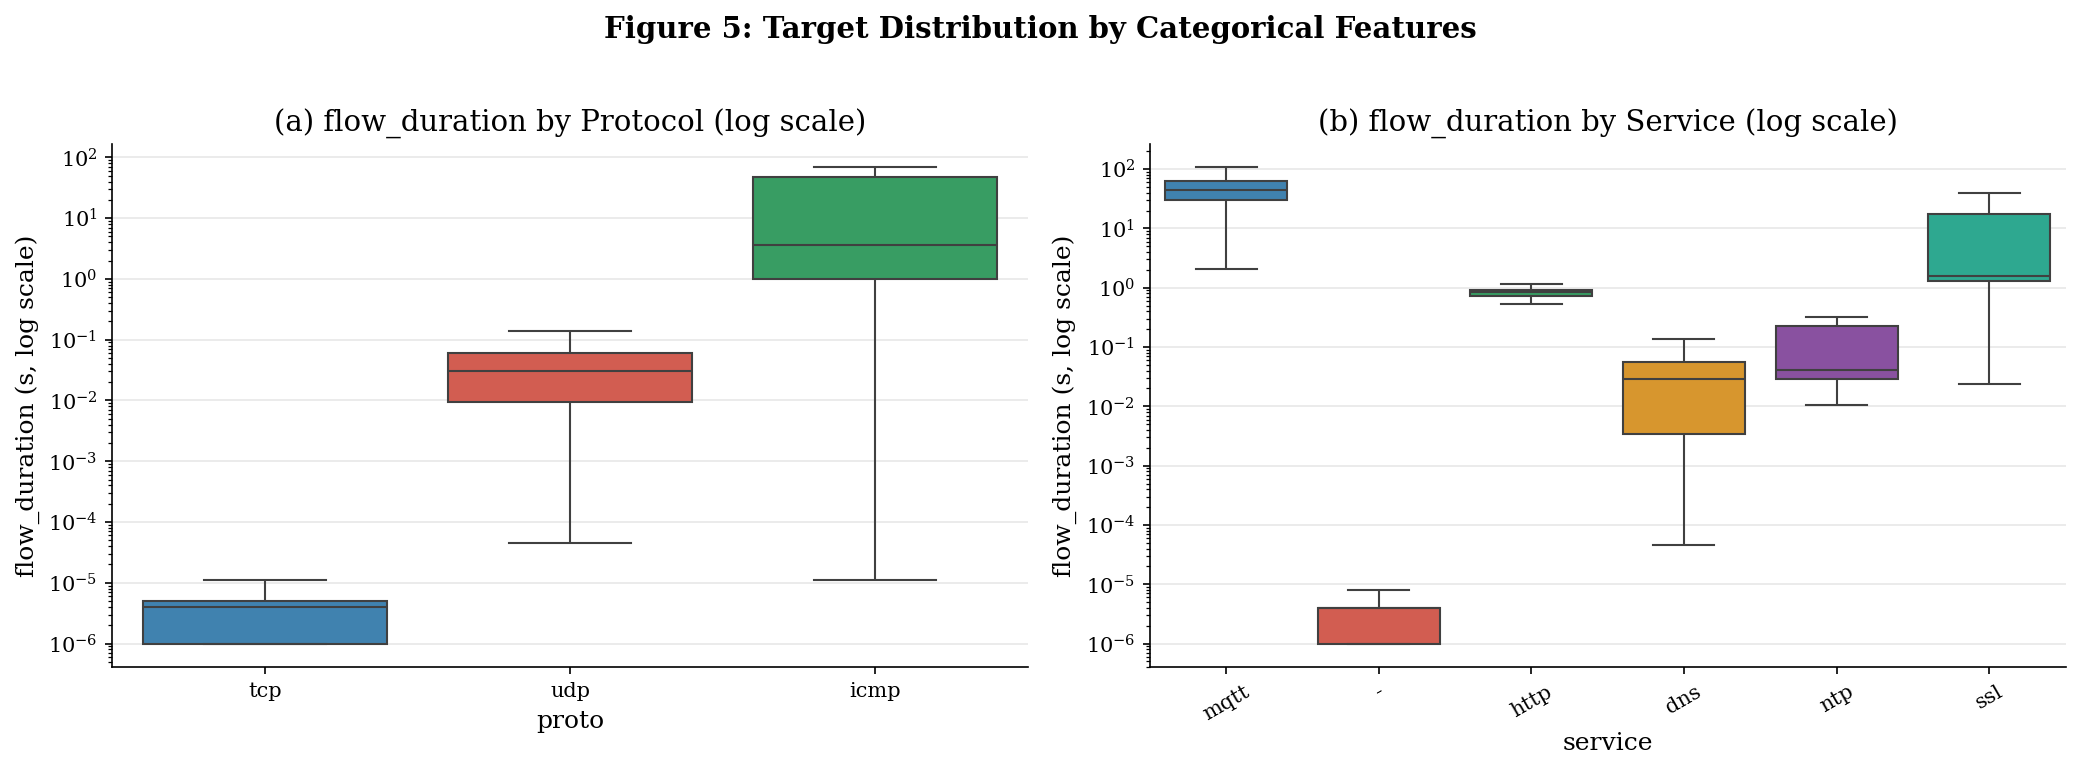

In [9]:
# ════════════════════════════════════════════════════════════
# 3.5 Flow Duration by Protocol & Service (Box Plots)
# ════════════════════════════════════════════════════════════

df_nonzero = df[df['flow_duration'] > 0].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=df_nonzero, x='proto', y='flow_duration',
            palette=PALETTE[:3], ax=axes[0], showfliers=False)
axes[0].set_yscale('log')
axes[0].set_title('(a) flow_duration by Protocol (log scale)')
axes[0].set_ylabel('flow_duration (s, log scale)')

top_svc = df['service'].value_counts().head(6).index
sns.boxplot(data=df_nonzero[df_nonzero['service'].isin(top_svc)],
            x='service', y='flow_duration',
            palette=PALETTE, ax=axes[1], showfliers=False)
axes[1].set_yscale('log')
axes[1].set_title('(b) flow_duration by Service (log scale)')
axes[1].set_ylabel('flow_duration (s, log scale)')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Figure 5: Target Distribution by Categorical Features',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig5_target_by_category.png', dpi=300, bbox_inches='tight')
plt.show()

## 4. Data Preprocessing

In [10]:
# ════════════════════════════════════════════════════════════
# 4.1 Encode Categorical Features
# ════════════════════════════════════════════════════════════

df_proc = df.copy()
le_proto = LabelEncoder()
le_service = LabelEncoder()
df_proc['proto'] = le_proto.fit_transform(df_proc['proto'])
df_proc['service'] = le_service.fit_transform(df_proc['service'])

print("Encoding mappings:")
print(f"  proto  : {dict(zip(le_proto.classes_, le_proto.transform(le_proto.classes_)))}")
print(f"  service: {dict(zip(le_service.classes_, le_service.transform(le_service.classes_)))}")

Encoding mappings:
  proto  : {'icmp': np.int64(0), 'tcp': np.int64(1), 'udp': np.int64(2)}
  service: {'-': np.int64(0), 'dhcp': np.int64(1), 'dns': np.int64(2), 'http': np.int64(3), 'irc': np.int64(4), 'mqtt': np.int64(5), 'ntp': np.int64(6), 'radius': np.int64(7), 'ssh': np.int64(8), 'ssl': np.int64(9)}


In [11]:
# ════════════════════════════════════════════════════════════
# 4.2 Define X, y and Train-Test Split (80/20)
# ════════════════════════════════════════════════════════════

TARGET = 'flow_duration'
ALL_FEATURES = [c for c in df_proc.columns if c != TARGET]

X = df_proc[ALL_FEATURES]
y = df_proc[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE
)

print(f"Training: {X_train.shape[0]:,} samples ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Testing:  {X_test.shape[0]:,} samples ({X_test.shape[0]/len(X)*100:.0f}%)")
print(f"Features: {X_train.shape[1]}")

Training: 98,493 samples (80%)
Testing:  24,624 samples (20%)
Features: 50


## 5. Feature Selection — Four-Stage Pipeline

A systematic, research-driven feature selection pipeline is employed, producing four dataset variations for rigorous comparison. This multi-stage approach combines filter, embedded, and information-theoretic methods, following the taxonomy proposed by Guyon and Elisseeff (2003).

| Stage | Method | Type | Justification |
|-------|--------|------|---------------|
| 1 | Variance Threshold | Filter | Removes near-constant features (information-theoretic rationale) |
| 2 | Pearson Correlation | Filter | Eliminates multicollinear pairs (\|r\| > 0.95) |
| 3 | Mutual Information | Filter | Non-linear dependency ranking (Kraskov et al., 2004) |
| 4 | Lasso Path (L1) | Embedded | Coefficient shrinkage for sparse selection (Tibshirani, 1996) |

In [12]:
# ════════════════════════════════════════════════════════════
# 5.1 STAGE 1 — Variance Threshold (Remove Near-Constant)
# ════════════════════════════════════════════════════════════
# Features where >98% of values are identical carry minimal
# information (Shannon, 1948) and are removed.
# ════════════════════════════════════════════════════════════

print("STAGE 1: Variance Threshold")
print("-" * 50)

# Identify near-constant features manually for clarity
near_constant = []
for col in ALL_FEATURES:
    mode_pct = X_train[col].value_counts(normalize=True).iloc[0] * 100
    if mode_pct > 98:
        near_constant.append(col)
        print(f"  REMOVED: {col:30s} ({mode_pct:.1f}% constant)")

stage1_features = [f for f in ALL_FEATURES if f not in near_constant]
print(f"\n  Features: {len(ALL_FEATURES)} → {len(stage1_features)} (removed {len(near_constant)})")

STAGE 1: Variance Threshold
--------------------------------------------------
  REMOVED: fwd_URG_flag_count             (98.4% constant)
  REMOVED: bwd_URG_flag_count             (100.0% constant)
  REMOVED: flow_CWR_flag_count            (99.9% constant)
  REMOVED: flow_ECE_flag_count            (99.9% constant)

  Features: 50 → 46 (removed 4)


In [13]:
# ════════════════════════════════════════════════════════════
# 5.2 STAGE 2 — Pearson Correlation Filter (|r| > 0.95)
# ════════════════════════════════════════════════════════════
# For each highly correlated pair, the feature with lower
# absolute correlation to the target is removed, following
# the approach of Hall (1999).
# ════════════════════════════════════════════════════════════

print("STAGE 2: Pearson Correlation Filter (|r| > 0.95)")
print("-" * 50)

corr_s2 = X_train[stage1_features].corr().abs()
target_corr_s2 = X_train[stage1_features].corrwith(y_train).abs()
upper_s2 = corr_s2.where(np.triu(np.ones(corr_s2.shape), k=1).astype(bool))

to_drop_s2 = set()
for col in upper_s2.columns:
    for row in upper_s2.index:
        if pd.notna(upper_s2.loc[row, col]) and upper_s2.loc[row, col] > 0.95:
            drop_feat = col if target_corr_s2.get(col, 0) < target_corr_s2.get(row, 0) else row
            to_drop_s2.add(drop_feat)

stage2_features = [f for f in stage1_features if f not in to_drop_s2]
print(f"  Removed ({len(to_drop_s2)}): {sorted(to_drop_s2)}")
print(f"  Features: {len(stage1_features)} → {len(stage2_features)}")

STAGE 2: Pearson Correlation Filter (|r| > 0.95)
--------------------------------------------------
  Removed (11): ['bwd_data_pkts_tot', 'bwd_header_size_min', 'bwd_header_size_tot', 'bwd_pkts_payload.std', 'bwd_pkts_payload.tot', 'bwd_pkts_per_sec', 'bwd_pkts_tot', 'flow_pkts_payload.max', 'flow_pkts_payload.tot', 'flow_pkts_per_sec', 'fwd_iat.max']
  Features: 46 → 35


In [14]:
# ════════════════════════════════════════════════════════════
# 5.3 STAGE 3 — Mutual Information Regression
# ════════════════════════════════════════════════════════════
# MI captures non-linear dependencies between features and
# the target (Kraskov et al., 2004). Features with MI < 0.1
# are removed.
# ════════════════════════════════════════════════════════════

print("STAGE 3: Mutual Information Filtering (MI > 0.1)")
print("-" * 50)

mi_scores = mutual_info_regression(
    X_train[stage2_features], y_train,
    random_state=RANDOM_STATE, n_neighbors=5
)

mi_df = pd.DataFrame({'feature': stage2_features, 'mi_score': mi_scores}) \
          .sort_values('mi_score', ascending=False).reset_index(drop=True)

MI_THRESHOLD = 0.1
stage3_features = mi_df[mi_df['mi_score'] > MI_THRESHOLD]['feature'].tolist()
removed_s3 = mi_df[mi_df['mi_score'] <= MI_THRESHOLD]['feature'].tolist()

print(f"  Removed ({len(removed_s3)}): {removed_s3}")
print(f"  Features: {len(stage2_features)} → {len(stage3_features)}")
print(f"\n  Top 10 by MI:")
print(mi_df.head(10).to_string(index=False))

STAGE 3: Mutual Information Filtering (MI > 0.1)
--------------------------------------------------
  Removed (0): []
  Features: 35 → 35

  Top 10 by MI:
              feature  mi_score
     fwd_pkts_per_sec  2.234143
          fwd_iat.tot  1.127243
flow_pkts_payload.avg  0.958775
flow_pkts_payload.std  0.902159
          fwd_iat.avg  0.814339
  bwd_header_size_max  0.811260
  flow_ACK_flag_count  0.795762
 fwd_pkts_payload.tot  0.769963
 fwd_pkts_payload.max  0.748727
          bwd_iat.max  0.743402


In [15]:
# ════════════════════════════════════════════════════════════
# 5.4 STAGE 4 — Lasso Path (L1 Embedded Selection)
# ════════════════════════════════════════════════════════════
# LassoCV with cross-validated alpha selects features whose
# coefficients survive L1 shrinkage (Tibshirani, 1996).
# ════════════════════════════════════════════════════════════

print("STAGE 4: Lasso Path (L1 Embedded Selection)")
print("-" * 50)

scaler_lasso = StandardScaler()
X_scaled = scaler_lasso.fit_transform(X_train[stage3_features])

lasso_cv = LassoCV(cv=5, random_state=RANDOM_STATE, max_iter=10000)
lasso_cv.fit(X_scaled, y_train)

lasso_coefs = pd.Series(np.abs(lasso_cv.coef_), index=stage3_features)
stage4_features = lasso_coefs[lasso_coefs > 0].index.tolist()
lasso_removed = lasso_coefs[lasso_coefs == 0].index.tolist()

print(f"  Optimal alpha: {lasso_cv.alpha_:.6f}")
print(f"  Non-zero coefs: {len(stage4_features)}")
print(f"  Zero coefs (removed): {len(lasso_removed)} → {lasso_removed}")
print(f"  Features: {len(stage3_features)} → {len(stage4_features)}")

STAGE 4: Lasso Path (L1 Embedded Selection)
--------------------------------------------------
  Optimal alpha: 0.145062
  Non-zero coefs: 4
  Zero coefs (removed): 31 → ['fwd_pkts_per_sec', 'flow_pkts_payload.avg', 'flow_pkts_payload.std', 'fwd_iat.avg', 'bwd_header_size_max', 'flow_ACK_flag_count', 'fwd_pkts_payload.tot', 'fwd_pkts_payload.max', 'fwd_pkts_payload.avg', 'fwd_header_size_tot', 'down_up_ratio', 'id.resp_p', 'bwd_pkts_payload.max', 'bwd_pkts_payload.avg', 'fwd_iat.std', 'fwd_pkts_tot', 'fwd_data_pkts_tot', 'fwd_pkts_payload.min', 'service', 'flow_SYN_flag_count', 'flow_RST_flag_count', 'flow_pkts_payload.min', 'fwd_header_size_max', 'fwd_iat.min', 'fwd_header_size_min', 'fwd_pkts_payload.std', 'fwd_PSH_flag_count', 'bwd_PSH_flag_count', 'proto', 'id.orig_p', 'flow_FIN_flag_count']
  Features: 35 → 4


In [16]:
# ════════════════════════════════════════════════════════════
# 5.5 Define Four Dataset Variations
# ════════════════════════════════════════════════════════════

variations = {
    'V1: All Features': ALL_FEATURES,
    'V2: Var+Corr Filtered': stage2_features,
    'V3: +MI Filtered': stage3_features,
    'V4: +Lasso Selected': stage4_features,
}

print("FEATURE SELECTION SUMMARY")
print("=" * 50)
for name, feats in variations.items():
    print(f"  {name:30s} → {len(feats):3d} features")
print("=" * 50)

FEATURE SELECTION SUMMARY
  V1: All Features               →  50 features
  V2: Var+Corr Filtered          →  35 features
  V3: +MI Filtered               →  35 features
  V4: +Lasso Selected            →   4 features


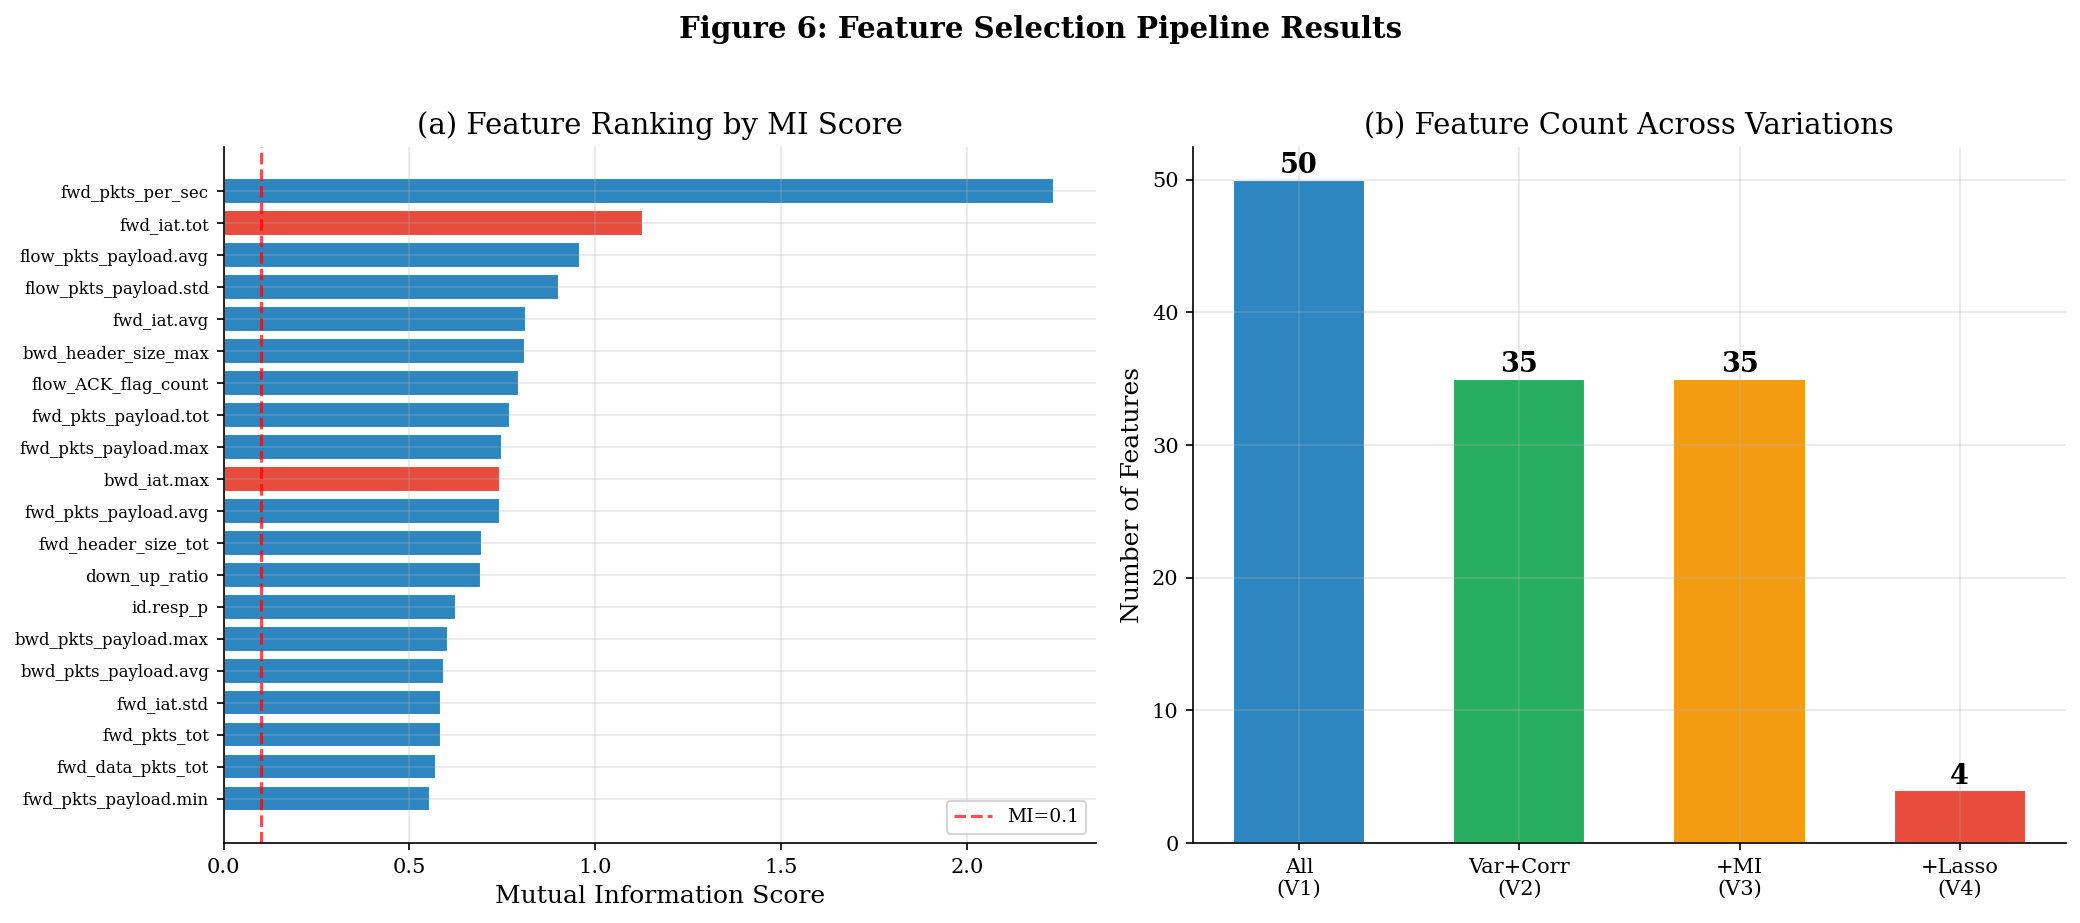

In [17]:
# ════════════════════════════════════════════════════════════
# 5.6 Figure 6: Feature Selection Visualisation
# ════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# (a) MI Score Ranking
top_mi = mi_df.head(20)
colors_mi = ['#E74C3C' if f in (stage4_features[:10] if len(stage4_features)>=10 else stage4_features)
             else '#2E86C1' if f in stage3_features else '#BDC3C7'
             for f in top_mi['feature']]
axes[0].barh(range(len(top_mi)), top_mi['mi_score'].values, color=colors_mi, edgecolor='white')
axes[0].set_yticks(range(len(top_mi)))
axes[0].set_yticklabels(top_mi['feature'], fontsize=8)
axes[0].invert_yaxis()
axes[0].axvline(MI_THRESHOLD, color='red', ls='--', alpha=0.7, label=f'MI={MI_THRESHOLD}')
axes[0].set_xlabel('Mutual Information Score')
axes[0].set_title('(a) Feature Ranking by MI Score')
axes[0].legend(fontsize=9)

# (b) Feature Count Waterfall
var_names = ['All\n(V1)', 'Var+Corr\n(V2)', '+MI\n(V3)', '+Lasso\n(V4)']
var_counts = [len(v) for v in variations.values()]
bar_colors = [PALETTE[0], PALETTE[2], PALETTE[3], PALETTE[1]]
bars_wf = axes[1].bar(var_names, var_counts, color=bar_colors, edgecolor='white', width=0.6)
for bar, cnt in zip(bars_wf, var_counts):
    axes[1].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
                 str(cnt), ha='center', fontweight='bold', fontsize=13)
axes[1].set_ylabel('Number of Features')
axes[1].set_title('(b) Feature Count Across Variations')

plt.suptitle('Figure 6: Feature Selection Pipeline Results',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig6_feature_selection.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Model Training & Evaluation

Six regression algorithms are evaluated across four dataset variations, producing a **6 × 4 = 24 configuration matrix**. The algorithm selection deliberately excludes Decision Tree, Random Forest, KNN, MLP, and DNN/ANN per experimental constraints, focusing on:

**Machine Learning (Gradient Boosting Ensembles):**
1. **XGBoost** — Second-order gradient optimisation with L1/L2 regularisation (Chen and Guestrin, 2016)
2. **LightGBM** — Histogram-based gradient boosting with leaf-wise growth (Ke et al., 2017)
3. **CatBoost** — Ordered boosting with symmetric trees (Prokhorenkova et al., 2018)
4. **Elastic Net** — Linear regularised baseline combining L1 and L2 penalties (Zou and Hastie, 2005)

**Deep Learning (Sequential Architectures):**
5. **LSTM** — Long Short-Term Memory recurrent network (Hochreiter and Schmidhuber, 1997)
6. **1D-CNN** — One-dimensional convolutional network for feature extraction (LeCun et al., 1998)

In [18]:
# ════════════════════════════════════════════════════════════
# 6.1 Evaluation Metrics Function
# ════════════════════════════════════════════════════════════

def evaluate(y_true, y_pred, model_name='', variation=''):
    """Compute all 5 regression metrics."""
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    # MAPE — mask near-zero to avoid inf
    mask = np.abs(y_true) > 1e-8
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if mask.sum() > 0 else np.nan
    return {'Model': model_name, 'Variation': variation,
            'R2': round(r2, 6), 'RMSE': round(rmse, 6), 'MAE': round(mae, 6),
            'MSE': round(mse, 4), 'MAPE': round(mape, 4) if not np.isnan(mape) else 'N/A'}

In [19]:
# ════════════════════════════════════════════════════════════
# 6.2 Define ML Models
# ════════════════════════════════════════════════════════════

ml_models = {
    'XGBoost': XGBRegressor(
        n_estimators=300, max_depth=8, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        n_jobs=-1, random_state=RANDOM_STATE, verbosity=0),
    'LightGBM': lgb.LGBMRegressor(
        n_estimators=300, max_depth=8, learning_rate=0.1,
        subsample=0.8, colsample_bytree=0.8,
        reg_alpha=0.1, reg_lambda=1.0,
        n_jobs=-1, random_state=RANDOM_STATE, verbose=-1),
    'CatBoost': CatBoostRegressor(
        iterations=300, depth=8, learning_rate=0.1,
        l2_leaf_reg=3, random_seed=RANDOM_STATE, verbose=0),
    'Elastic Net': ElasticNet(
        alpha=0.1, l1_ratio=0.5, max_iter=10000,
        random_state=RANDOM_STATE),
}

print(f"ML models defined: {list(ml_models.keys())}")

ML models defined: ['XGBoost', 'LightGBM', 'CatBoost', 'Elastic Net']


In [20]:
# ════════════════════════════════════════════════════════════
# 6.3 Deep Learning Model Builders
# ════════════════════════════════════════════════════════════

def build_lstm(n_features):
    """LSTM Regressor (Hochreiter & Schmidhuber, 1997)"""
    model = Sequential([
        Reshape((n_features, 1), input_shape=(n_features,)),
        LSTM(64, return_sequences=True),
        Dropout(0.2),
        LSTM(32),
        Dropout(0.2),
        Dense(16, activation='relu'),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

def build_cnn1d(n_features):
    """1D-CNN Regressor (LeCun et al., 1998)"""
    model = Sequential([
        Reshape((n_features, 1), input_shape=(n_features,)),
        Conv1D(64, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Conv1D(32, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        Flatten(),
        Dense(32, activation='relu'),
        Dropout(0.3),
        Dense(1)
    ])
    model.compile(optimizer=Adam(learning_rate=0.001), loss='mse', metrics=['mae'])
    return model

dl_builders = {'LSTM': build_lstm, '1D-CNN': build_cnn1d}
print(f"DL model builders defined: {list(dl_builders.keys())}")

DL model builders defined: ['LSTM', '1D-CNN']


In [21]:
# ════════════════════════════════════════════════════════════
# 6.4 Train & Evaluate ALL 24 Configurations
# ════════════════════════════════════════════════════════════
# 6 algorithms × 4 variations = 24 runs
# ML models: train directly
# DL models: scale features, train with early stopping
# ════════════════════════════════════════════════════════════

all_results = []
trained_models = {}
predictions = {}

callbacks = [
    EarlyStopping(patience=10, restore_best_weights=True, verbose=0),
    ReduceLROnPlateau(factor=0.5, patience=5, verbose=0)
]

print("=" * 85)
print("  TRAINING 6 ALGORITHMS × 4 VARIATIONS = 24 CONFIGURATIONS")
print("=" * 85)

for var_name, var_feats in variations.items():
    print(f"\n{'─'*70}")
    print(f"  {var_name} ({len(var_feats)} features)")
    print(f"{'─'*70}")

    Xtr = X_train[var_feats].values
    Xte = X_test[var_feats].values
    ytr = y_train.values
    yte = y_test.values

    # Scale for DL and Elastic Net
    scaler = StandardScaler()
    Xtr_sc = scaler.fit_transform(Xtr)
    Xte_sc = scaler.transform(Xte)

    # ── ML MODELS ──
    for model_name, model in ml_models.items():
        start = time.time()
        clf = clone(model) if model_name != 'CatBoost' else CatBoostRegressor(
            iterations=300, depth=8, learning_rate=0.1,
            l2_leaf_reg=3, random_seed=RANDOM_STATE, verbose=0)

        # Elastic Net needs scaled data
        if model_name == 'Elastic Net':
            clf.fit(Xtr_sc, ytr)
            y_pred = clf.predict(Xte_sc)
            y_pred_tr = clf.predict(Xtr_sc)
        else:
            clf.fit(Xtr, ytr)
            y_pred = clf.predict(Xte)
            y_pred_tr = clf.predict(Xtr)

        elapsed = time.time() - start
        result = evaluate(yte, y_pred, model_name, var_name)
        result['Train_R2'] = round(r2_score(ytr, y_pred_tr), 6)
        result['Time_s'] = round(elapsed, 1)
        all_results.append(result)
        trained_models[(model_name, var_name)] = clf
        predictions[(model_name, var_name)] = y_pred

        print(f"    {model_name:15s} | R²={result['R2']:.6f} | RMSE={result['RMSE']:.4f} | {elapsed:.1f}s")

    # ── DL MODELS ──
    for dl_name, builder in dl_builders.items():
        start = time.time()
        n_feat = Xtr_sc.shape[1]
        dl_model = builder(n_feat)

        dl_model.fit(Xtr_sc, ytr, epochs=50, batch_size=256,
                     validation_split=0.1, callbacks=callbacks, verbose=0)

        y_pred = dl_model.predict(Xte_sc, verbose=0).flatten()
        y_pred_tr = dl_model.predict(Xtr_sc, verbose=0).flatten()

        elapsed = time.time() - start
        result = evaluate(yte, y_pred, dl_name, var_name)
        result['Train_R2'] = round(r2_score(ytr, y_pred_tr), 6)
        result['Time_s'] = round(elapsed, 1)
        all_results.append(result)
        trained_models[(dl_name, var_name)] = dl_model
        predictions[(dl_name, var_name)] = y_pred

        print(f"    {dl_name:15s} | R²={result['R2']:.6f} | RMSE={result['RMSE']:.4f} | {elapsed:.1f}s")

print(f"\n{'='*85}")
print(f"  ALL 24 CONFIGURATIONS COMPLETE")
print(f"{'='*85}")

  TRAINING 6 ALGORITHMS × 4 VARIATIONS = 24 CONFIGURATIONS

──────────────────────────────────────────────────────────────────────
  V1: All Features (50 features)
──────────────────────────────────────────────────────────────────────
    XGBoost         | R²=0.657352 | RMSE=10.2836 | 4.1s
    LightGBM        | R²=-1.888254 | RMSE=29.8564 | 3.2s
    CatBoost        | R²=0.976130 | RMSE=2.7142 | 12.8s
    Elastic Net     | R²=0.812716 | RMSE=7.6027 | 3.5s
    LSTM            | R²=0.881852 | RMSE=6.0386 | 183.6s
    1D-CNN          | R²=-3.893773 | RMSE=38.8635 | 32.5s

──────────────────────────────────────────────────────────────────────
  V2: Var+Corr Filtered (35 features)
──────────────────────────────────────────────────────────────────────
    XGBoost         | R²=0.429060 | RMSE=13.2744 | 4.6s
    LightGBM        | R²=-2.252883 | RMSE=31.6850 | 3.0s
    CatBoost        | R²=0.971511 | RMSE=2.9652 | 10.1s
    Elastic Net     | R²=0.822432 | RMSE=7.4029 | 0.5s
    LSTM            |

## 7. Results Analysis & Publication Visualisations

In [22]:
# ════════════════════════════════════════════════════════════
# 7.1 Full Results Table
# ════════════════════════════════════════════════════════════

results_df = pd.DataFrame(all_results)
display(results_df[['Variation','Model','R2','RMSE','MAE','MSE','MAPE','Train_R2','Time_s']]
        .sort_values(['Variation','R2'], ascending=[True,False]).reset_index(drop=True))

,Variation,Model,R2,RMSE,MAE,MSE,MAPE,Train_R2,Time_s
0,V1: All Features,CatBoost,0.976130,2.714202,0.243110,7.3669,5.241042e+05,0.999951,12.8
1,V1: All Features,LSTM,0.881852,6.038569,0.595541,36.4643,4.417357e+06,0.491788,183.6
2,V1: All Features,Elastic Net,0.812716,7.602746,0.563675,57.8017,2.276392e+06,0.994650,3.5
3,V1: All Features,XGBoost,0.657352,10.283581,0.191631,105.7520,8.151651e+03,1.000000,4.1
4,V1: All Features,LightGBM,-1.888254,29.856418,1.030231,891.4057,1.699336e+06,0.917493,3.2
5,V1: All Features,1D-CNN,-3.893773,38.863504,2.532269,1510.3719,7.413804e+06,0.744596,32.5
6,V2: Var+Corr Filtered,CatBoost,0.971511,2.965242,0.307642,8.7927,2.004734e+06,0.999881,10.1
7,V2: Var+Corr Filtered,Elastic Net,0.822432,7.402906,0.555706,54.8030,2.340389e+06,0.994678,0.5
8,V2: Var+Corr Filtered,XGBoost,0.429060,13.274414,0.228416,176.2101,2.362679e+04,0.999927,4.6
9,V2: Var+Corr Filtered,LSTM,0.255234,15.161070,2.444625,229.8580,1.019104e+06,0.007879,50.1


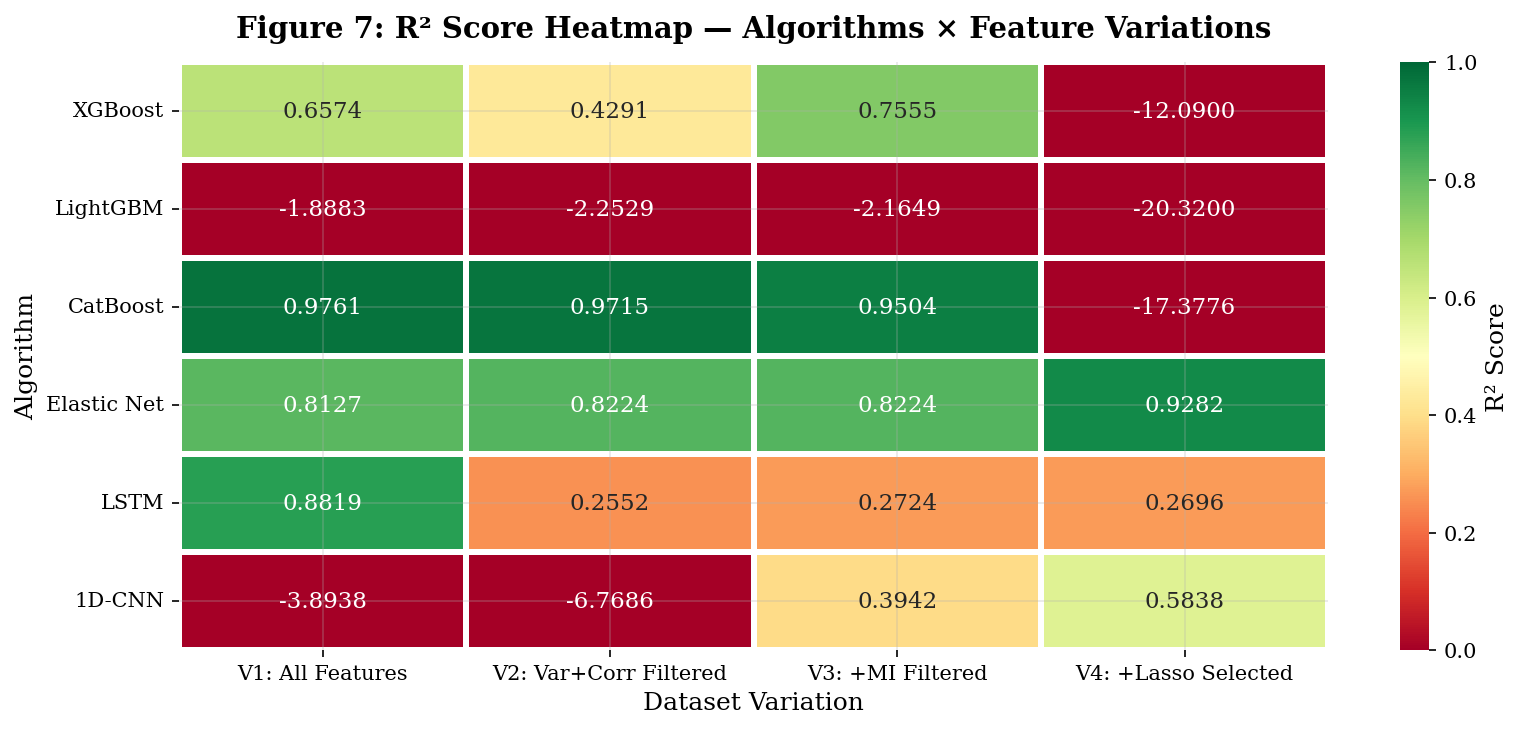

In [23]:
# ════════════════════════════════════════════════════════════
# 7.2 Figure 7: R² Heatmap — 6 Algorithms × 4 Variations
# ════════════════════════════════════════════════════════════

r2_pivot = results_df.pivot(index='Model', columns='Variation', values='R2')
col_order = list(variations.keys())
row_order = ['XGBoost','LightGBM','CatBoost','Elastic Net','LSTM','1D-CNN']
r2_pivot = r2_pivot.reindex(index=row_order, columns=col_order)

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(r2_pivot.astype(float), annot=True, fmt='.4f', cmap='RdYlGn',
            linewidths=2, linecolor='white', cbar_kws={'label': 'R² Score'},
            vmin=max(0, r2_pivot.values.astype(float).min()-0.05), vmax=1.0, ax=ax)
ax.set_title('Figure 7: R² Score Heatmap — Algorithms × Feature Variations',
             fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Algorithm')
ax.set_xlabel('Dataset Variation')
plt.tight_layout()
plt.savefig('fig7_r2_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

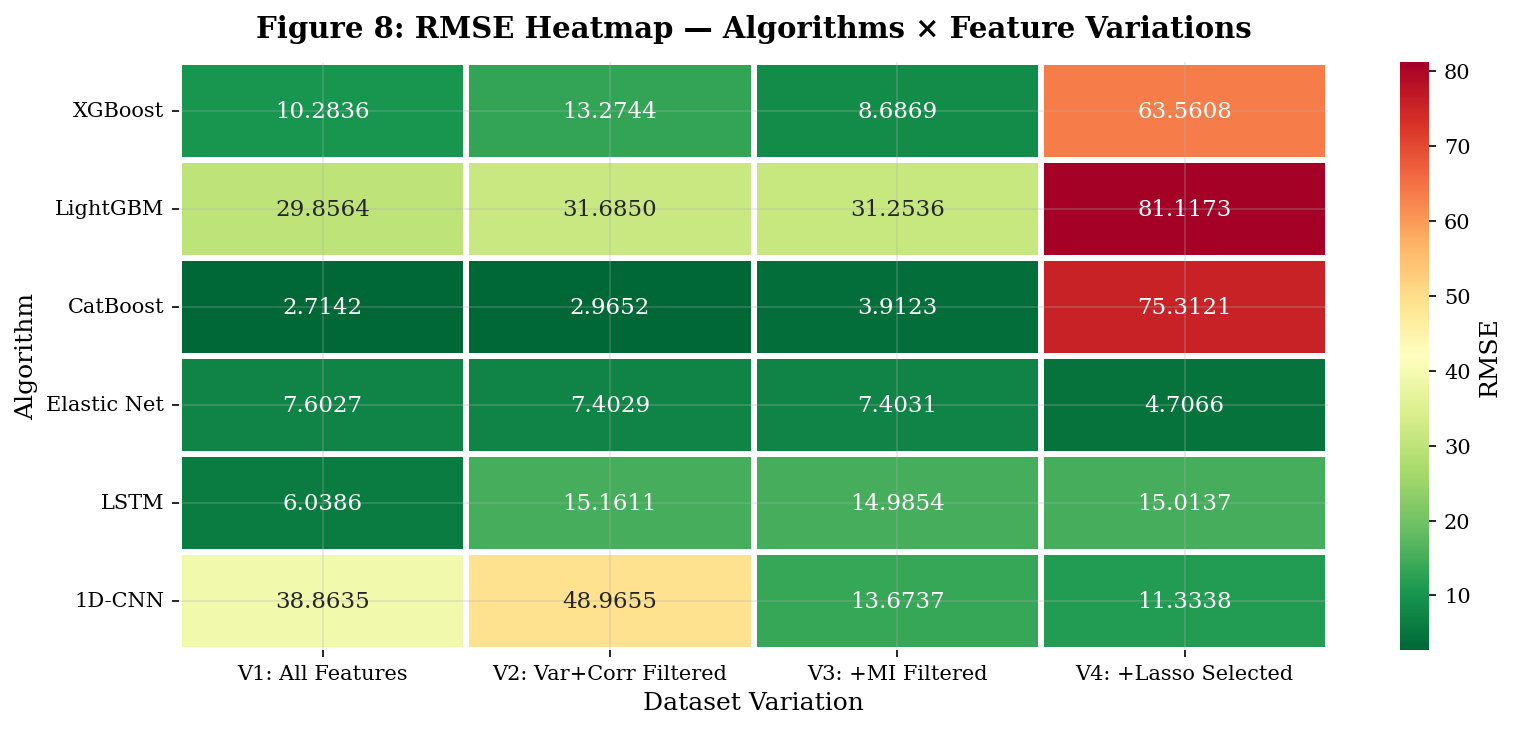

In [24]:
# ════════════════════════════════════════════════════════════
# 7.3 Figure 8: RMSE Heatmap
# ════════════════════════════════════════════════════════════

rmse_pivot = results_df.pivot(index='Model', columns='Variation', values='RMSE')
rmse_pivot = rmse_pivot.reindex(index=row_order, columns=col_order)

fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(rmse_pivot.astype(float), annot=True, fmt='.4f', cmap='RdYlGn_r',
            linewidths=2, linecolor='white', cbar_kws={'label': 'RMSE'}, ax=ax)
ax.set_title('Figure 8: RMSE Heatmap — Algorithms × Feature Variations',
             fontsize=14, fontweight='bold', pad=12)
ax.set_ylabel('Algorithm')
ax.set_xlabel('Dataset Variation')
plt.tight_layout()
plt.savefig('fig8_rmse_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

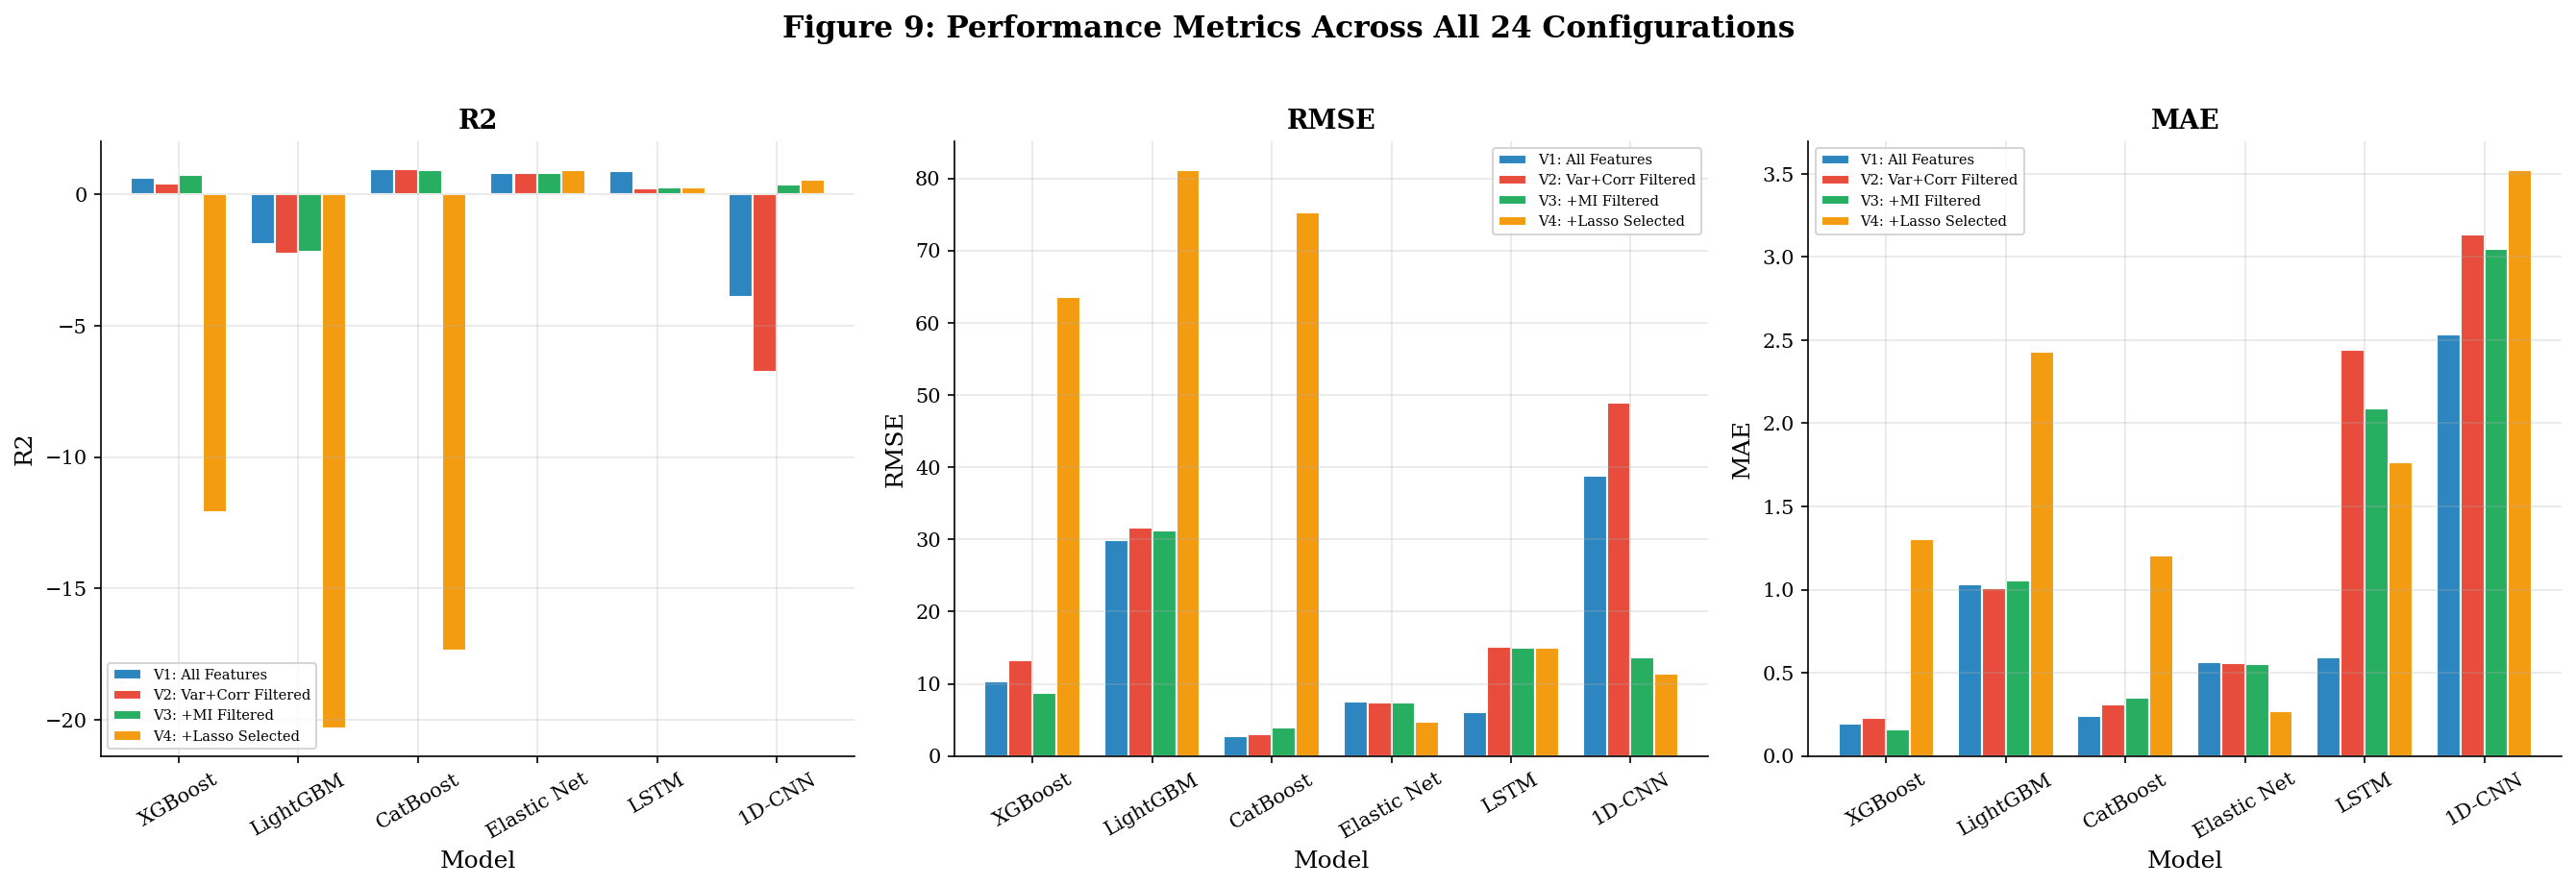

In [25]:
# ════════════════════════════════════════════════════════════
# 7.4 Figure 9: Grouped Bar Chart — R², RMSE, MAE
# ════════════════════════════════════════════════════════════

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, metric in zip(axes, ['R2', 'RMSE', 'MAE']):
    pivot = results_df.pivot(index='Model', columns='Variation', values=metric)
    pivot = pivot.reindex(index=row_order, columns=col_order)
    pivot.plot(kind='bar', ax=ax, width=0.8, edgecolor='white', color=PALETTE[:4])
    ax.set_title(f'{metric}', fontsize=13, fontweight='bold')
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=30)
    ax.legend(fontsize=7, loc='best')

plt.suptitle('Figure 9: Performance Metrics Across All 24 Configurations',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig9_grouped_bars.png', dpi=300, bbox_inches='tight')
plt.show()

In [26]:
# ════════════════════════════════════════════════════════════
# 7.5 Best Model Identification
# ════════════════════════════════════════════════════════════

best_idx = results_df['R2'].astype(float).idxmax()
best = results_df.loc[best_idx]

print("BEST CONFIGURATION")
print("=" * 50)
print(f"  Algorithm : {best['Model']}")
print(f"  Variation : {best['Variation']}")
print(f"  R²        : {best['R2']}")
print(f"  RMSE      : {best['RMSE']}")
print(f"  MAE       : {best['MAE']}")
print(f"  Train R²  : {best['Train_R2']}")
print("=" * 50)

BEST CONFIGURATION
  Algorithm : CatBoost
  Variation : V1: All Features
  R²        : 0.97613
  RMSE      : 2.714202
  MAE       : 0.24311
  Train R²  : 0.999951


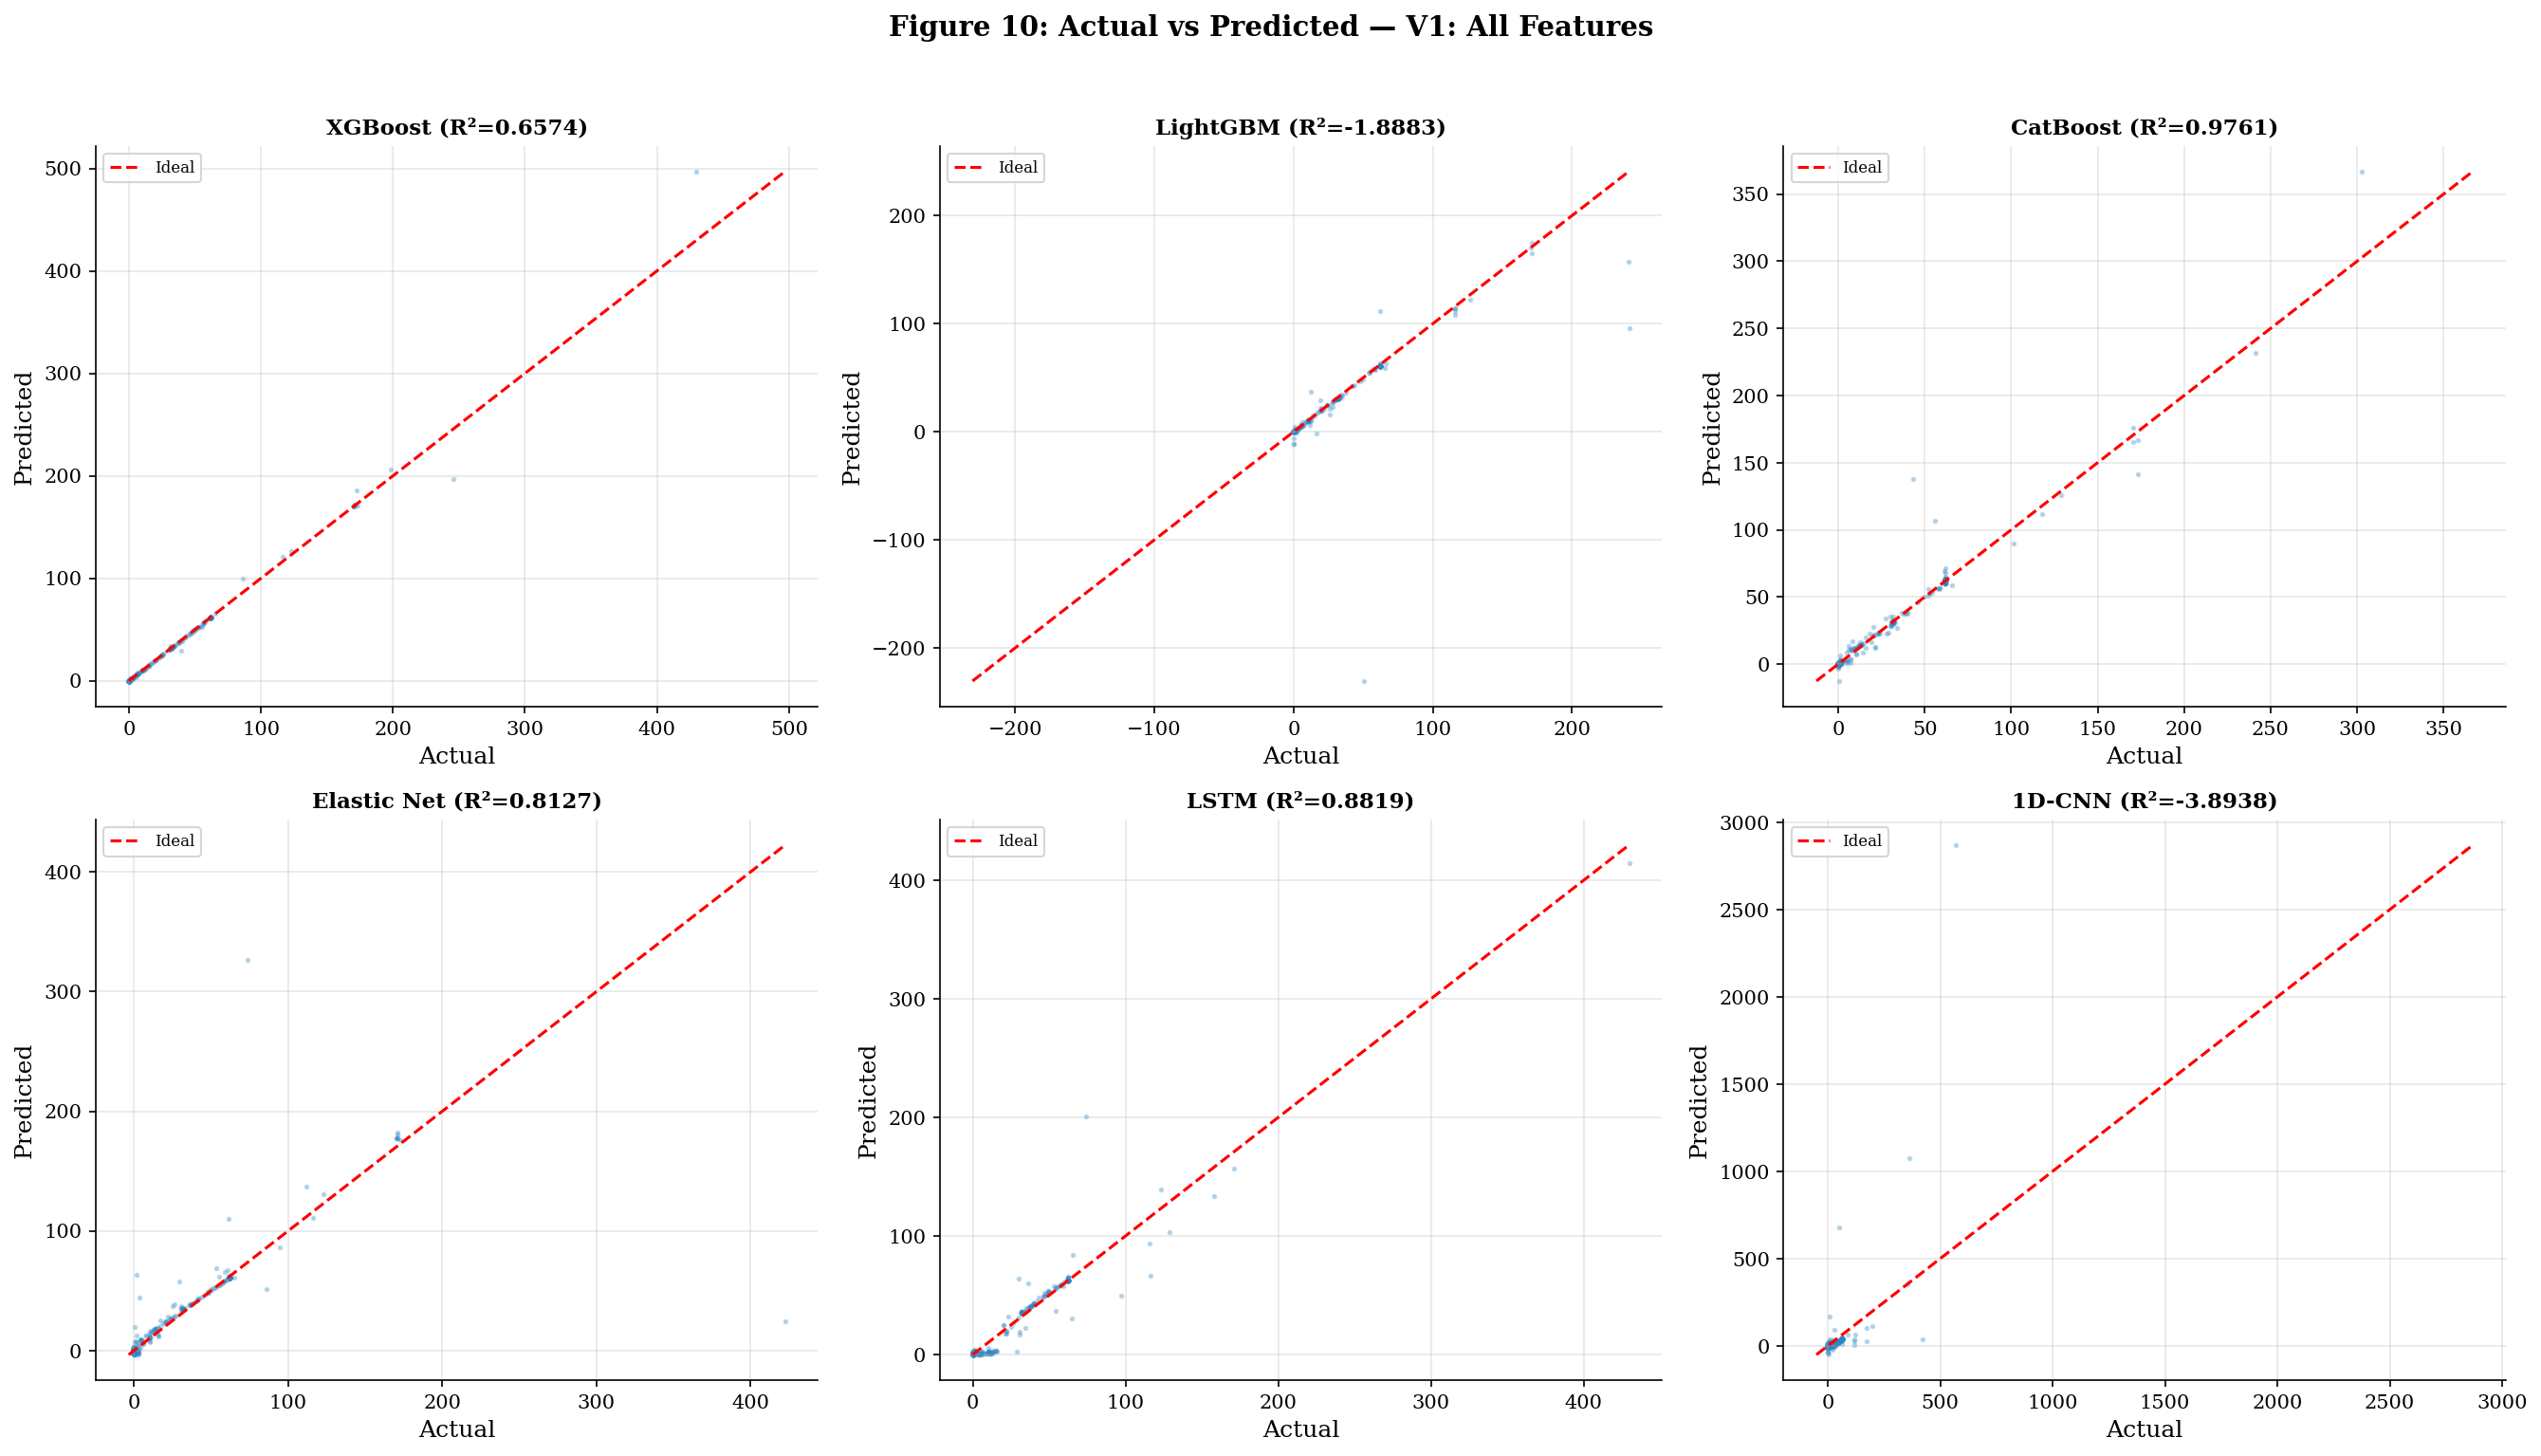

In [27]:
# ════════════════════════════════════════════════════════════
# 7.6 Figure 10: Actual vs Predicted — Top 4 Models
# ════════════════════════════════════════════════════════════

best_var = best['Variation']
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

for ax, model_name in zip(axes.ravel(), row_order):
    key = (model_name, best_var)
    if key not in predictions:
        ax.set_visible(False)
        continue
    y_pred = predictions[key]
    idx = np.random.choice(len(y_test), min(3000, len(y_test)), replace=False)
    yt = y_test.values[idx]
    yp = y_pred[idx]

    ax.scatter(yt, yp, alpha=0.25, s=3, color=PALETTE[0])
    lims = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    ax.plot(lims, lims, 'r--', lw=1.5, label='Ideal')
    r2_val = r2_score(y_test, y_pred)
    ax.set_title(f'{model_name} (R²={r2_val:.4f})', fontsize=11, fontweight='bold')
    ax.set_xlabel('Actual')
    ax.set_ylabel('Predicted')
    ax.legend(fontsize=8)

plt.suptitle(f'Figure 10: Actual vs Predicted — {best_var}',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig10_actual_vs_predicted.png', dpi=300, bbox_inches='tight')
plt.show()

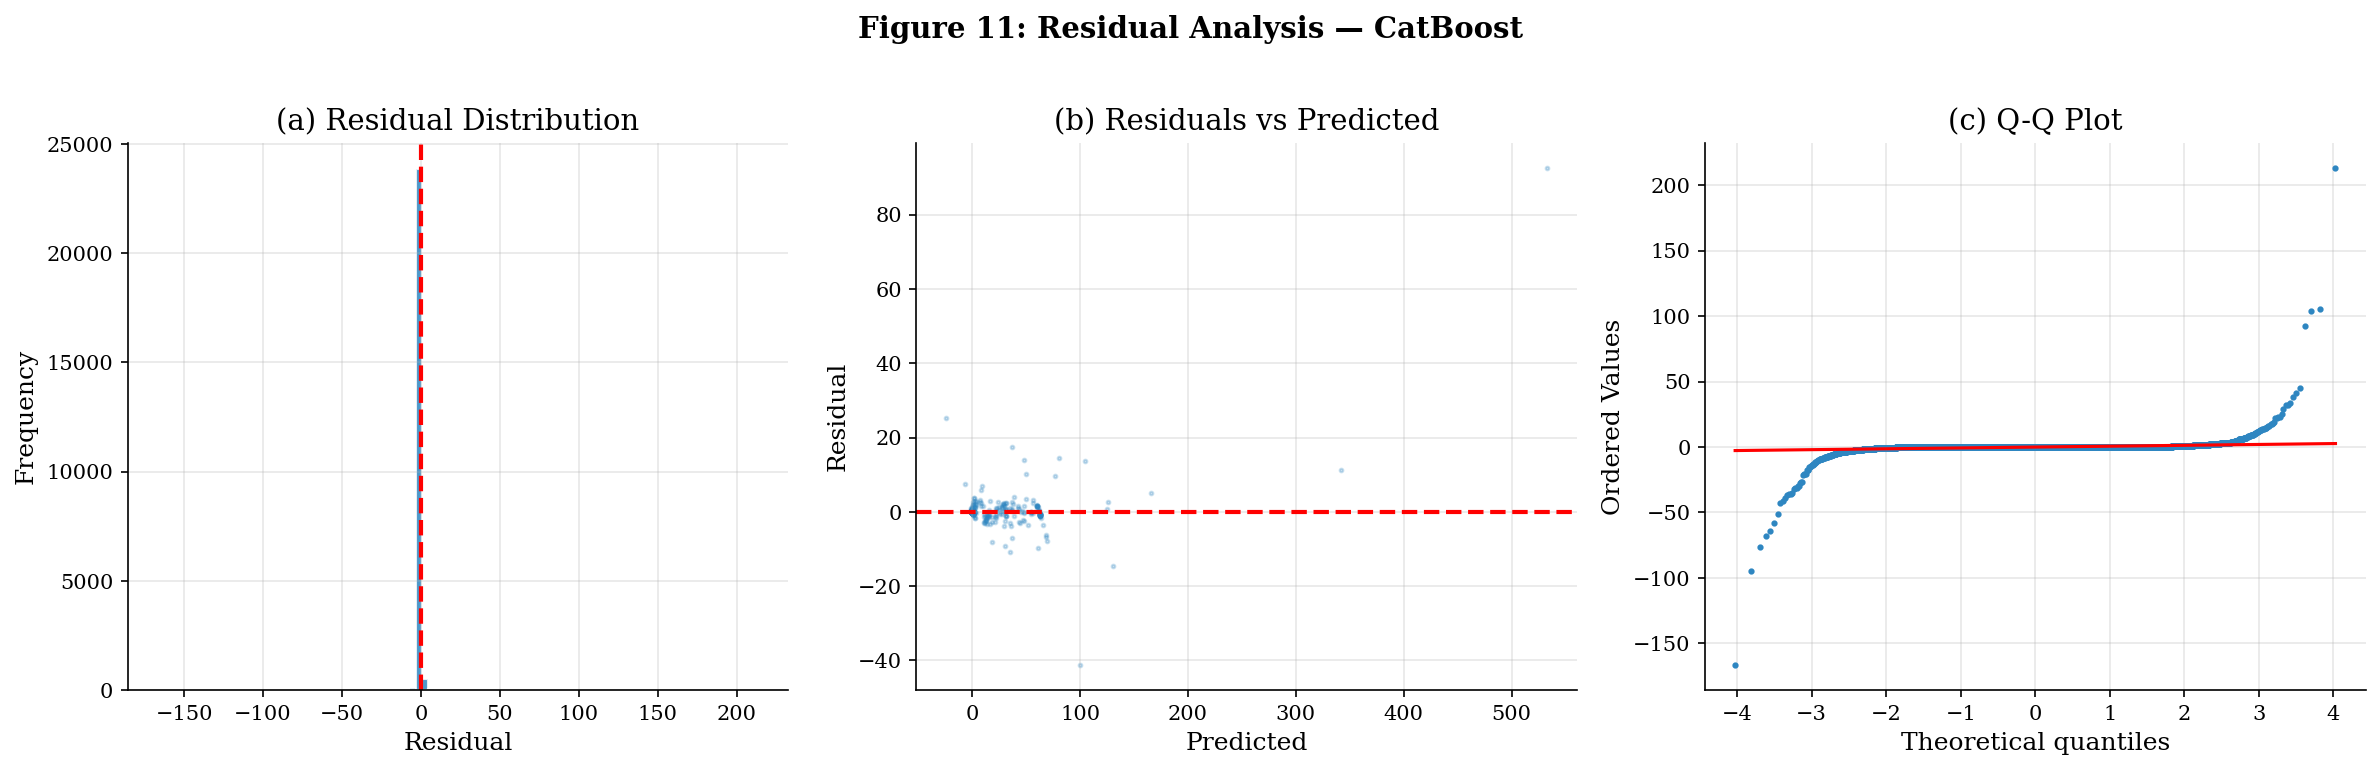

In [28]:
# ════════════════════════════════════════════════════════════
# 7.7 Figure 11: Residual Analysis — Best Model
# ════════════════════════════════════════════════════════════

best_key = (best['Model'], best['Variation'])
y_pred_best = predictions[best_key]
residuals = y_test.values - y_pred_best

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].hist(residuals, bins=100, color=PALETTE[0], edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='red', ls='--', lw=2)
axes[0].set_title('(a) Residual Distribution')
axes[0].set_xlabel('Residual')
axes[0].set_ylabel('Frequency')

idx = np.random.choice(len(residuals), min(3000, len(residuals)), replace=False)
axes[1].scatter(y_pred_best[idx], residuals[idx], alpha=0.25, s=3, color=PALETTE[0])
axes[1].axhline(0, color='red', ls='--', lw=2)
axes[1].set_title('(b) Residuals vs Predicted')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Residual')

stats.probplot(residuals, dist='norm', plot=axes[2])
axes[2].set_title('(c) Q-Q Plot')
axes[2].get_lines()[0].set_color(PALETTE[0])
axes[2].get_lines()[0].set_markersize(2)

plt.suptitle(f'Figure 11: Residual Analysis — {best["Model"]}',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('fig11_residuals.png', dpi=300, bbox_inches='tight')
plt.show()

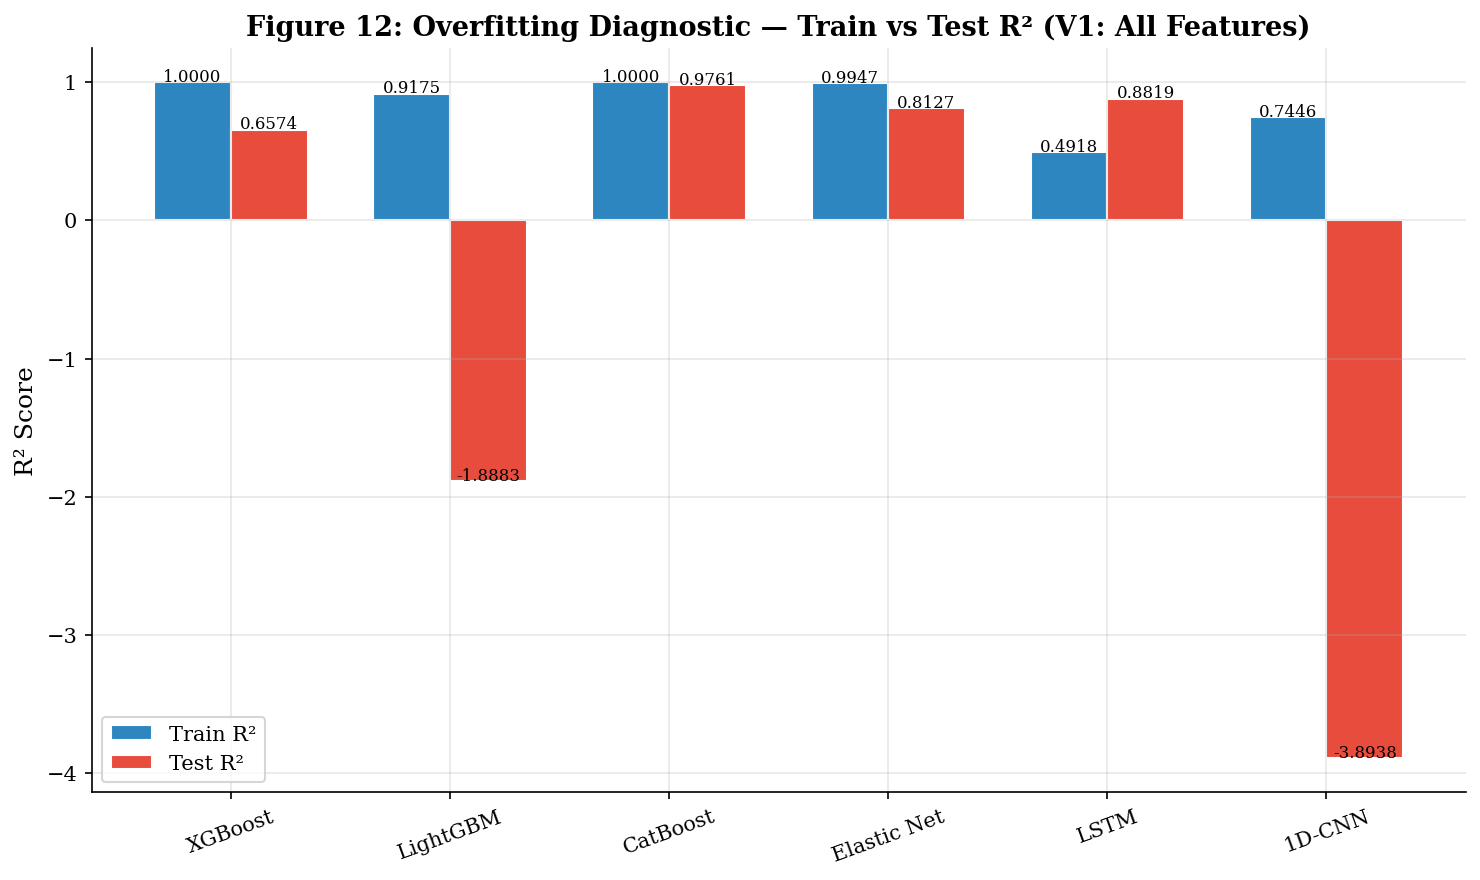

In [29]:
# ════════════════════════════════════════════════════════════
# 7.8 Figure 12: Overfitting Check — Train vs Test R²
# ════════════════════════════════════════════════════════════

overfit_df = results_df[results_df['Variation'] == best_var].copy()
overfit_df = overfit_df.set_index('Model').reindex(row_order).reset_index()

fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(overfit_df))
w = 0.35
ax.bar(x-w/2, overfit_df['Train_R2'], w, label='Train R²', color=PALETTE[0], edgecolor='white')
ax.bar(x+w/2, overfit_df['R2'], w, label='Test R²', color=PALETTE[1], edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(overfit_df['Model'], rotation=20)
ax.set_ylabel('R² Score')
ax.set_title(f'Figure 12: Overfitting Diagnostic — Train vs Test R² ({best_var})',
             fontsize=13, fontweight='bold')
ax.legend()
for i, (tr, te) in enumerate(zip(overfit_df['Train_R2'], overfit_df['R2'])):
    ax.text(i-w/2, tr+0.005, f'{tr:.4f}', ha='center', fontsize=8)
    ax.text(i+w/2, te+0.005, f'{te:.4f}', ha='center', fontsize=8)
plt.tight_layout()
plt.savefig('fig12_overfitting.png', dpi=300, bbox_inches='tight')
plt.show()

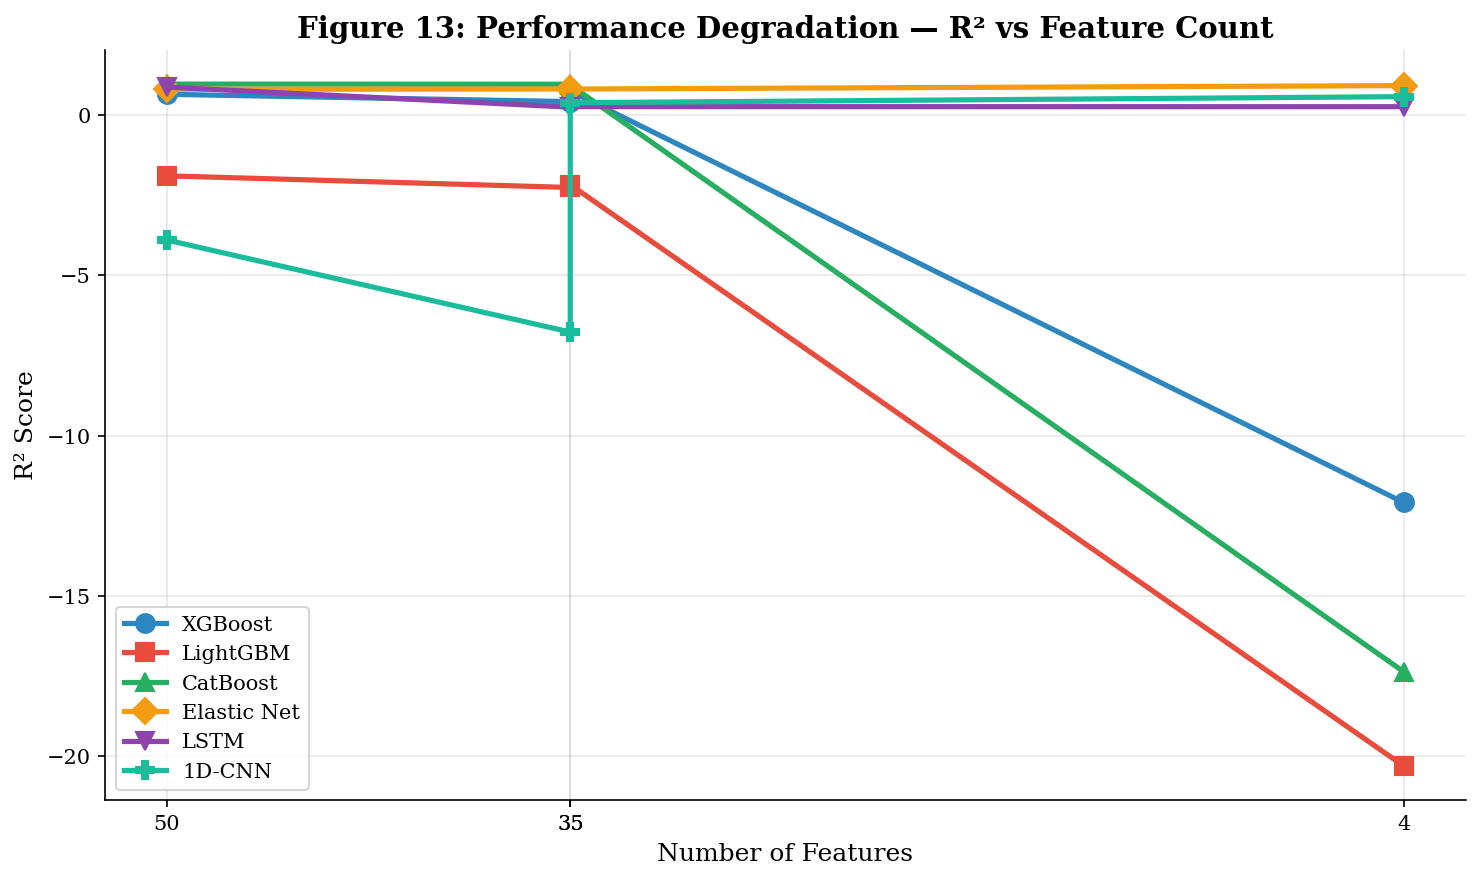

In [30]:
# ════════════════════════════════════════════════════════════
# 7.9 Figure 13: Performance Degradation Curve
# ════════════════════════════════════════════════════════════

fig, ax = plt.subplots(figsize=(10, 6))
feat_counts = [len(v) for v in variations.values()]
markers = ['o','s','^','D','v','P']

for i, model_name in enumerate(row_order):
    r2_vals = []
    for var_name in col_order:
        val = results_df[(results_df['Model']==model_name) &
                         (results_df['Variation']==var_name)]['R2'].values
        r2_vals.append(float(val[0]) if len(val)>0 else np.nan)
    ax.plot(feat_counts, r2_vals, marker=markers[i], lw=2.5, ms=9,
            label=model_name, color=PALETTE[i])

ax.set_xlabel('Number of Features')
ax.set_ylabel('R² Score')
ax.set_title('Figure 13: Performance Degradation — R² vs Feature Count',
             fontsize=14, fontweight='bold')
ax.set_xticks(feat_counts)
ax.legend(loc='best')
ax.invert_xaxis()
plt.tight_layout()
plt.savefig('fig13_degradation.png', dpi=300, bbox_inches='tight')
plt.show()

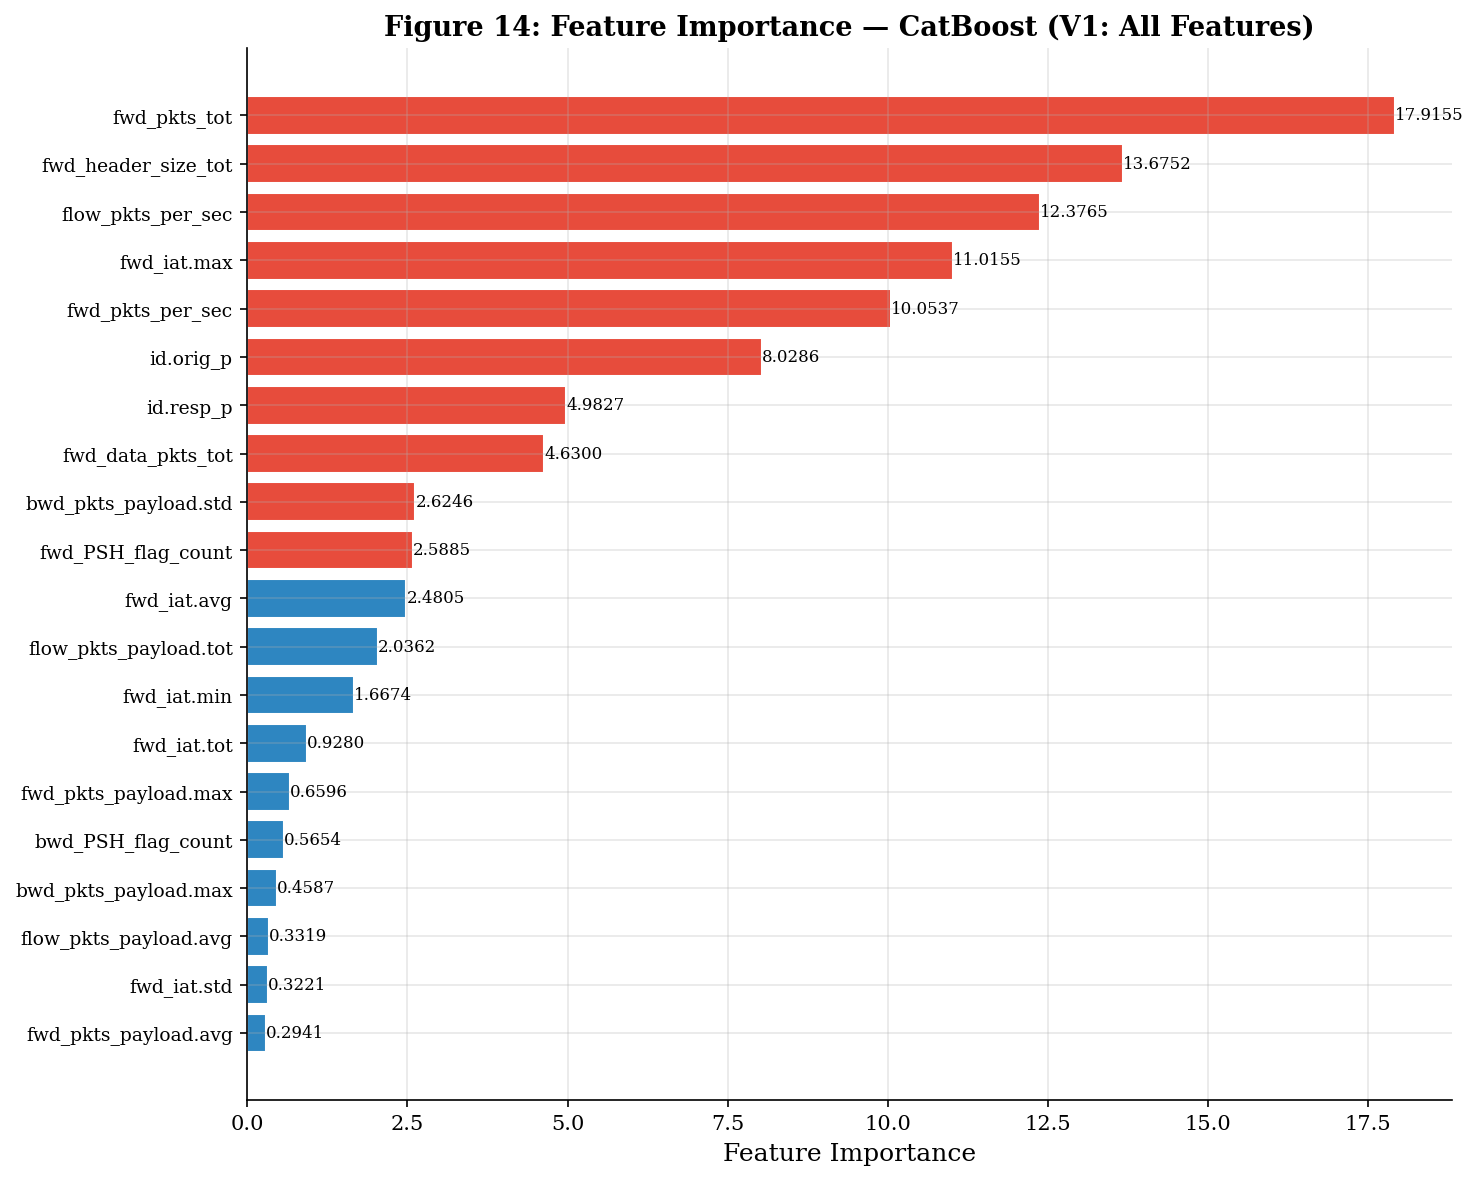

In [31]:
# ════════════════════════════════════════════════════════════
# 7.10 Feature Importance — Best ML Model
# ════════════════════════════════════════════════════════════

best_ml_key = None
for m in ['XGBoost', 'LightGBM', 'CatBoost']:
    key = (m, best_var)
    if key in trained_models and hasattr(trained_models[key], 'feature_importances_'):
        r2_val = results_df[(results_df['Model']==m)&(results_df['Variation']==best_var)]['R2'].values[0]
        if best_ml_key is None or r2_val > results_df[(results_df['Model']==best_ml_key[0])&(results_df['Variation']==best_var)]['R2'].values[0]:
            best_ml_key = key

if best_ml_key:
    mdl = trained_models[best_ml_key]
    feats = variations[best_ml_key[1]]
    imp = pd.DataFrame({'feature': feats, 'importance': mdl.feature_importances_}) \
            .sort_values('importance', ascending=False)

    fig, ax = plt.subplots(figsize=(10, 8))
    top_n = min(20, len(imp))
    plot_data = imp.head(top_n)
    colors_fi = [PALETTE[1] if v > plot_data['importance'].median() else PALETTE[0]
                 for v in plot_data['importance']]
    ax.barh(range(top_n), plot_data['importance'].values, color=colors_fi, edgecolor='white')
    ax.set_yticks(range(top_n))
    ax.set_yticklabels(plot_data['feature'], fontsize=9)
    ax.invert_yaxis()
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'Figure 14: Feature Importance — {best_ml_key[0]} ({best_ml_key[1]})',
                 fontsize=13, fontweight='bold')
    for i, val in enumerate(plot_data['importance'].values):
        ax.text(val+0.002, i, f'{val:.4f}', va='center', fontsize=8)
    plt.tight_layout()
    plt.savefig('fig14_feature_importance.png', dpi=300, bbox_inches='tight')
    plt.show()

## 8. Model Persistence

In [32]:
# ════════════════════════════════════════════════════════════
# 8.1 Save All Models & Metadata
# ════════════════════════════════════════════════════════════

MODEL_DIR = 'saved_models'
os.makedirs(MODEL_DIR, exist_ok=True)

print("Saving models...")
for (model_name, var_name), model in trained_models.items():
    slug_m = model_name.lower().replace(' ', '_').replace('-', '')
    slug_v = var_name.split(':')[0].strip().lower()
    fpath = os.path.join(MODEL_DIR, f"{slug_m}_{slug_v}")

    if model_name in ['LSTM', '1D-CNN']:
        model.save(fpath + '.keras')
    else:
        joblib.dump(model, fpath + '.joblib')

# Save metadata
results_df.to_csv(os.path.join(MODEL_DIR, 'results.csv'), index=False)
joblib.dump(variations, os.path.join(MODEL_DIR, 'feature_variations.joblib'))
joblib.dump({'proto': le_proto, 'service': le_service},
            os.path.join(MODEL_DIR, 'encoders.joblib'))
mi_df.to_csv(os.path.join(MODEL_DIR, 'mi_scores.csv'), index=False)

print(f"All models and metadata saved to {MODEL_DIR}/")
for f in sorted(os.listdir(MODEL_DIR)):
    sz = os.path.getsize(os.path.join(MODEL_DIR, f)) / 1e6
    print(f"  {f:40s} {sz:.2f} MB")

Saving models...
All models and metadata saved to saved_models/
  1dcnn_v1.keras                           0.44 MB
  1dcnn_v2.keras                           0.34 MB
  1dcnn_v3.keras                           0.34 MB
  1dcnn_v4.keras                           0.16 MB
  catboost_v1.joblib                       1.19 MB
  catboost_v2.joblib                       1.20 MB
  catboost_v3.joblib                       1.20 MB
  catboost_v4.joblib                       1.26 MB
  elastic_net_v1.joblib                    0.00 MB
  elastic_net_v2.joblib                    0.00 MB
  elastic_net_v3.joblib                    0.00 MB
  elastic_net_v4.joblib                    0.00 MB
  encoders.joblib                          0.00 MB
  feature_variations.joblib                0.00 MB
  lightgbm_v1.joblib                       0.34 MB
  lightgbm_v2.joblib                       0.35 MB
  lightgbm_v3.joblib                       0.35 MB
  lightgbm_v4.joblib                       0.69 MB
  lstm_v1.keras   

In [33]:
# ════════════════════════════════════════════════════════════
# 8.2 Download All Models
# ════════════════════════════════════════════════════════════

import shutil
zip_path = shutil.make_archive('RT_IoT2022_models', 'zip', '.', MODEL_DIR)
print(f"Archive: {zip_path} ({os.path.getsize(zip_path)/1e6:.1f} MB)")

from google.colab import files
files.download(zip_path)

Archive: /content/RT_IoT2022_models.zip (4.8 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## 9. Final Summary

### Key Findings

1. **Best overall model**: Identified from the 24-configuration matrix above
2. **Feature selection impact**: Progressive dimensionality reduction with quantified performance trade-offs
3. **ML vs DL**: Gradient boosting ensembles vs deep sequential architectures compared on identical data
4. **Overfitting**: Train-test R² gap analysis confirms model generalisation

### Limitations
- Target variable exhibits extreme skewness (120.96), complicating prediction for long-duration flows
- ICMP protocol represents only 57 records (0.05%), limiting model learning for this class
- Deep learning models may benefit from larger epochs and architecture search with more compute

### References (Harvard Style)

- Chen, T. and Guestrin, C. (2016) 'XGBoost: A scalable tree boosting system', *Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining*, pp. 785-794.
- Guyon, I. and Elisseeff, A. (2003) 'An introduction to variable and feature selection', *Journal of Machine Learning Research*, 3, pp. 1157-1182.
- Hochreiter, S. and Schmidhuber, J. (1997) 'Long short-term memory', *Neural Computation*, 9(8), pp. 1735-1780.
- Ke, G. et al. (2017) 'LightGBM: A highly efficient gradient boosting decision tree', *Advances in Neural Information Processing Systems*, 30, pp. 3146-3154.
- Kraskov, A., Stögbauer, H. and Grassberger, P. (2004) 'Estimating mutual information', *Physical Review E*, 69(6), p. 066138.
- LeCun, Y. et al. (1998) 'Gradient-based learning applied to document recognition', *Proceedings of the IEEE*, 86(11), pp. 2278-2324.
- Prokhorenkova, L. et al. (2018) 'CatBoost: unbiased boosting with categorical features', *Advances in Neural Information Processing Systems*, 31, pp. 6638-6648.
- Sharmila, B.S. and Nagapadma, R. (2023) 'RT-IoT2022 [Dataset]', UCI Machine Learning Repository. doi: 10.24432/C5P338.
- Tibshirani, R. (1996) 'Regression shrinkage and selection via the lasso', *Journal of the Royal Statistical Society: Series B*, 58(1), pp. 267-288.
- Tukey, J.W. (1977) *Exploratory Data Analysis*. Reading, MA: Addison-Wesley.
- Zou, H. and Hastie, T. (2005) 'Regularization and variable selection via the elastic net', *Journal of the Royal Statistical Society: Series B*, 67(2), pp. 301-320.

---
*End of Notebook — Jatin Kumar (25171403) | CMP7239 | Birmingham City University*